# ***Thesis Project by Group CLS***

***THESIS 1-3***

**Thesis Project**

**Group Members:**
*   Celles, Aaron Kent M.
*   Leviste, Lee Ryan A.
*   Santeco, Enrique S.

# ***Section 1. Introduction***

## **1.1 Problem Overview**

---



Large-scale global optimization (LSGO) presents a critical challenge in computational intelligence, where the "curse of dimensionality" leads to an explosive increase in local optima and a high risk of premature convergence. While foundational algorithms like Differential Evolution (DE) are robust, their dependence on crossover and random mutation may restrict guided exploration — reducing particle diversity over time and leading to premature convergence.

This notebook implements and evaluates the proposed **Diversity-Preserving Level-Based Learning Differential Evolution (DP-LLDE)** algorithm, tested against the **CEC 2017 Large-Scale Global Optimization Benchmark** across 29 benchmark functions (F1–F30, excluding deprecated F2) at **10 dimensions**.

## **1.2 Research Objectives**

---



1. Design and implement DP-LLDE, integrating sequential relative particle mutation and dynamic level-based learning into the Differential Evolution framework.
2. Evaluate DP-LLDE on the CEC 2017 benchmark suite (F1–F30) at 10 dimensions.
3. Examine convergence behavior, solution quality, and the effect of diversity-preserving strategies across unimodal, multimodal, hybrid, and composition functions.

## **1.3 Algorithm Overview - DP-LLDE**

---


DP-LLDE extends LBLDE (Qiao et al., 2022) with three core contributions:

1. **Sequential Level Assignment** — each individual is assigned a learning source level drawn randomly from {2, …, NL} on the first generation, decaying toward the elite level (level 1) in subsequent generations.
2. **Diversity-Aware Exemplar Selection** — if two exemplars e1, e2 fall below a diversity threshold, one is replaced with the most distant candidate in that level, preventing exemplar collapse.
3. **Normalized Mutation Pressure (Eq. 10):**

$$V_i = e_1 + F_i \times (e_2 - X_i) \times \frac{NL - k}{NL}$$

The factor $(NL-k)/NL$ decays to zero as $k \to NL$, naturally reducing mutation pressure as learning quality improves.

| Parameter | Value |
|-----------|-------|
| Population Size (NP) | 100 |
| Number of Levels (NL) | 4 |
| Initial μ_CR | 0.35 |
| Max FES | 10,000 × D |
| Dimensions (D) | 10 |
| Seed | 42 |

# ***Section 2. Benchmark Function Description***

## **2.1 Overview**

---


The **CEC 2017 Large-Scale Global Optimization Benchmark** (Awad et al., 2017) is a standardized suite of 30 test functions designed to evaluate optimization algorithms on complex, high-dimensional search spaces. The benchmark tests an algorithm's ability to avoid false local optima, convergence speed, and solution accuracy.

All functions are defined over the search space $[-100, 100]^D$ with their respective global optima offset by a function-specific bias value.

> **Library used:** `cec2017` by Duncan Tilley — provides the official shift vectors, rotation matrices, and shuffle permutations from the CEC 2017 specification.

## **2.2 Unimodal Function Overview**

---


Unimodal functions contain a **single global optimum and no local optima**. They are used to test the convergence speed and accuracy of an algorithm in a straightforward landscape.

| No. | Function Name | Global Optimum |
|-----|--------------|----------------|
| F1 | Shifted and Rotated Bent Cigar | 100 |
| F2 | Shifted and Rotated Sum of Different Power *(Deprecated)* | 200 |
| F3 | Shifted and Rotated Zakharov | 300 |

> **Note:** F2 is officially deprecated from the CEC 2017 benchmark but is included here for completeness as it remains implemented in the `cec2017` library.

## **2.3 Multimodal Function Overview**

---


Multimodal functions contain **multiple local optima**, making them significantly harder to solve. They are used to evaluate an algorithm's capacity to avoid premature convergence and escape false local optima.

| No. | Function Name | Global Optimum |
|-----|--------------|----------------|
| F4 | Shifted and Rotated Rosenbrock's | 400 |
| F5 | Shifted and Rotated Rastrigin's | 500 |
| F6 | Shifted and Rotated Expanded Schaffer's F6 | 600 |
| F7 | Shifted and Rotated Lunacek Bi-Rastrigin | 700 |
| F8 | Shifted and Rotated Non-Continuous Rastrigin's | 800 |
| F9 | Shifted and Rotated Levy | 900 |
| F10 | Shifted and Rotated Schwefel's | 1000 |

## **2.4 Hybrid Function Overview**

---


Hybrid functions divide the search space into several regions, each governed by a **different basic function**. They assess an algorithm's adaptability to heterogeneous landscapes and mixed search behaviors.

| No. | Component Functions | Global Optimum |
|-----|-------------------|----------------|
| F11 | Zakharov; Rosenbrock; Rastrigin | 1100 |
| F12 | Elliptic; Schwefel; Bent Cigar | 1200 |
| F13 | Bent Cigar; Rosenbrock; Bi-Rastrigin | 1300 |
| F14 | Elliptic; Ackley; Schaffer F7; Rastrigin | 1400 |
| F15 | Bent Cigar; HGBat; Rastrigin; Rosenbrock | 1500 |
| F16 | Schaffer F6; HGBat; Rosenbrock; Schwefel | 1600 |
| F17 | Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin | 1700 |
| F18 | Elliptic; Ackley; Rastrigin; HGBat; Discus | 1800 |
| F19 | Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer F6 | 1900 |
| F20 | HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer F7 | 2000 |

## **2.5 Composite Function Overview**

---


Composition functions **combine multiple shifted and rotated basic functions** into a single search space, creating highly complex and deceptive optimization landscapes. They are the most challenging category in the CEC 2017 suite and significantly test an algorithm's overall robustness and global search capability.

| No. | Component Functions | Global Optimum |
|-----|-------------------|----------------|
| F21 | Rosenbrock; Elliptic; Rastrigin | 2100 |
| F22 | Rastrigin; Griewank; Schwefel | 2200 |
| F23 | Rosenbrock; Ackley; Schwefel; Rastrigin | 2300 |
| F24 | Ackley; Elliptic; Griewank; Rastrigin | 2400 |
| F25 | Rastrigin; HappyCat; Ackley; Discus; Rosenbrock | 2500 |
| F26 | Schaffer F6; Schwefel; Griewank; Rosenbrock; Rastrigin | 2600 |
| F27 | HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer F6 | 2700 |
| F28 | Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer F6 | 2800 |
| F29 | F15; F16; F17 | 2900 |
| F30 | F15; F18; F19 | 3000 |

# ***Section 3. List of Required Libraries***

## **3.1 List of Libraries and Versions**

---



The following libraries and modules were used for optimization, benchmarking, and visualization in this project:

| Library / Module      | Purpose                                                                 | Version         |
|-----------------------|-------------------------------------------------------------------------|-----------------|
| `python`              | Core programming language                                               | 3.10+           |
| `numpy`               | Numerical computing and array operations                                | 2.0.2           |
| `matplotlib`          | Plotting and saving convergence graphs                                  | 3.10.0          |
| `cec2017`             | CEC 2017 benchmark functions (simple, hybrid, composition)              | Latest (pip)    |
| `cec2017.simple`      | Simple benchmark functions F1–F10                                       | —               |
| `cec2017.hybrid`      | Hybrid benchmark functions F11–F20                                      | —               |
| `cec2017.composition` | Composition benchmark functions F21–F30                                 | —               |
| `dpllde`              | DP-LLDE optimization algorithm (uploaded locally)                       | Custom          |
| `google.colab.files`  | File upload utility for loading `dpllde.py` into the Colab environment  | Built-in        |
| `sys`                 | Clears cached module before re-importing `dpllde.py`                    | Built-in        |

# ***Section 4. Environment Setup and Validation***





## **4.1 Installation**

Install `cec2017`

In [1]:
!pip install cec2017 --quiet

ERROR: Could not find a version that satisfies the requirement cec2017 (from versions: none)
ERROR: No matching distribution found for cec2017


## **4.2 File Validation**

Import `simple.py`, `hybrid.py`, and `composition.py` python files for benchmark functions

In [2]:
from cec2017 import simple, hybrid, composition
print('cec2017 loaded!')

cec2017 loaded!


Import `sys` control over warning messages for verification that `dpllde.py` exists

In [3]:
from google.colab import files
import sys

uploaded = files.upload()

if 'dpllde.py' in uploaded:
    if 'dpllde' in sys.modules:
        del sys.modules['dpllde']
    import dpllde
    from dpllde import DPLLDE
    print('dpllde.py uploaded and imported successfully!')
else:
    print('ERROR: Please upload a file named dpllde.py')

Saving dpllde.py to dpllde.py
dpllde.py uploaded and imported successfully!


# ***Section 5. Configuration and Helper Functions***

---



## **5.1 Library Imports**

Import libraries `numpy`, `matplotlib`, and `cec2017` for numerical computation, visualization, and CEC 2017 benchmark functions.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from cec2017 import simple, hybrid, composition

## **5.2 Global Parameters**

Define global parameters

In [5]:
D = 10 # Change this when testing different dimensions

In [6]:
bounds = np.array([[-100.0, 100.0]] * D)
MAX_FES = 10000 * D
NP, NL, MU_CR = 100, 4, 0.35
SEED = 42

Store all results for summary table under `all_results` dict

In [7]:
all_results = {}

## **5.3 Function Definitions**

Define `make_wrapper` to adapt CEC 2017 functions to accept a 1D input array from DP-LLDE, returning a large penalty value if the output is invalid (nan/inf).


In [8]:
def make_wrapper(fn):
    """Wrap a cec2017 function (expects (1,D) input) to accept (D,) input."""
    def wrapper(x):
        val = fn(x.reshape(1, -1))
        if hasattr(val, '__len__'):
            val = float(val[0])
        else:
            val = float(val)
        return val if np.isfinite(val) else 1e18
    return wrapper

Define `run_and_plot` to execute a single DP-LLDE optimization run on a given benchmark function, print the results, store them for the summary table, and save the convergence graph.

In [9]:
def run_and_plot(fn_name, fn_eval, f_global, fn_label):
    """Run DP-LLDE on a function and plot convergence graph."""
    print('=' * 80)
    print(f'DP-LLDE on CEC 2017 {fn_name} — Single Run')
    print('=' * 80)
    print(f'Function       : {fn_label} ({D}D)')
    print(f'Bounds         : [-100, 100]')
    print(f'Global optimum : {f_global}')

    opt = DPLLDE(
        objective_func=fn_eval,
        bounds=bounds,
        NP=NP, NL=NL, mu_CR_ini=MU_CR,
        max_fes=MAX_FES,
        seed=SEED
    )
    best_sol, best_fit, history = opt.optimize(verbose=True)

    error = abs(best_fit - f_global)
    print(f'\n{"="*80}')
    print('Results:')
    print(f'  Best Fitness           : {best_fit:.6e}')
    print(f'  Global Optimum         : {f_global:.6e}')
    print(f'  Error (|best-optimum|) : {error:.6e}')
    print(f'  Best Solution (5 dim)  : {best_sol[:5]}')
    print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
    print(f'{"="*80}')

    # Store for summary
    all_results[fn_name] = {
        'label': fn_label,
        'best_fit': best_fit,
        'f_global': f_global,
        'error': error
    }

    # Plot
    fes_axis = np.linspace(0, MAX_FES, len(history))
    plt.figure(figsize=(10, 6))
    plt.plot(fes_axis, history, color='steelblue', linewidth=1.5)
    plt.xlabel('Function Evaluations (FEs)', fontsize=12)
    plt.ylabel('Best Fitness', fontsize=12)
    plt.title(f'DP-LLDE Convergence — CEC 2017 {fn_name}: {fn_label} ({D}D)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.tight_layout()
    fname = f'convergence_{fn_name}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Graph saved as {fname}\n')

print('All wrappers and helpers defined. Ready to run functions.')

All wrappers and helpers defined. Ready to run functions.


# ***Section 6. CEC2017 Benchmark Functions***

---



## **6.1 Unimodal Functions (F1-F3)**

DP-LLDE on CEC 2017 F1 — Single Run
Function       : Shifted and Rotated Bent Cigar (10D)
Bounds         : [-100, 100]
Global optimum : 100.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.871674e+11
Generation   10: Best = 2.358231e+10  FES =   1100  μ_F = 0.595  μ_CR = 0.353
Generation   20: Best = 2.836411e+09  FES =   2100  μ_F = 0.648  μ_CR = 0.360
Generation   30: Best = 1.320003e+09  FES =   3100  μ_F = 0.682  μ_CR = 0.371
Generation   40: Best = 4.067197e+08  FES =   4100  μ_F = 0.694  μ_CR = 0.367
Generation   50: Best = 1.425156e+08  FES =   5100  μ_F = 0.719  μ_CR = 0.366
Generation   60: Best = 1.425156e+08  FES =   6100  μ_F = 0.707  μ_CR = 0.348
Generation   70: Best = 6.727673e+07  FES =   7100  μ_F = 0.732  μ_CR = 0.340
Generation   80: Best = 1.587221e+07  FES =   8100  μ_F = 0.743  μ_CR = 0.329
Generation   90: Best = 1.587221e+07  FES =   9100  μ_F = 0.751  μ_CR = 0.328
Generation  100: Best = 4.114547e+06  FES =  10100

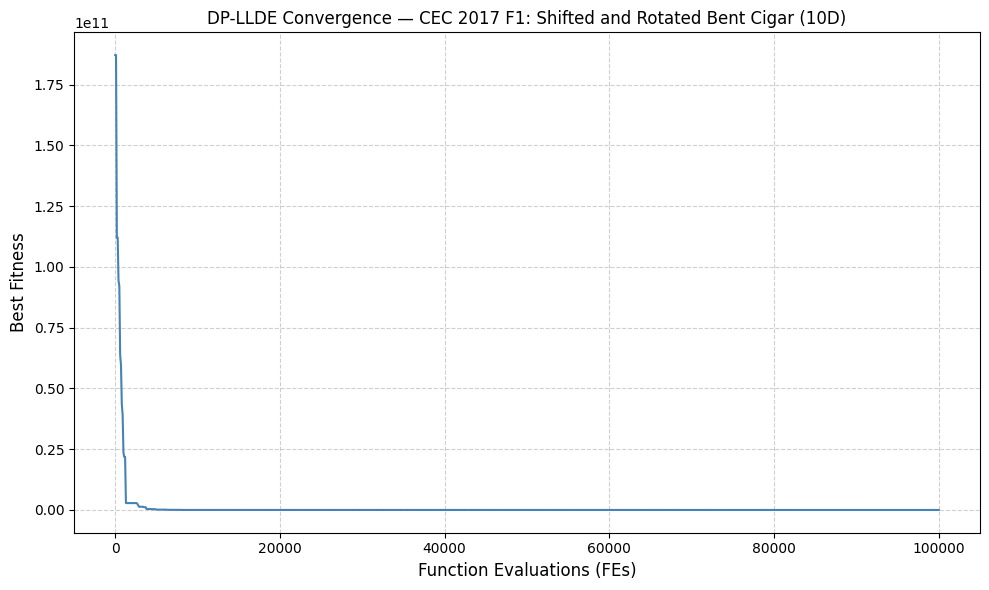

Graph saved as convergence_F1.png



In [10]:
# ============================================================
# F1 — Shifted and Rotated Bent Cigar
# ============================================================
run_and_plot('F1', make_wrapper(simple.f1), 100.0, 'Shifted and Rotated Bent Cigar')

DP-LLDE on CEC 2017 F2 — Single Run
Function       : Shifted and Rotated Sum of Different Power (Deprecated) (10D)
Bounds         : [-100, 100]
Global optimum : 200.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.603565e+14
Generation   10: Best = 8.009984e+09  FES =   1100  μ_F = 0.575  μ_CR = 0.349
Generation   20: Best = 1.835752e+08  FES =   2100  μ_F = 0.636  μ_CR = 0.366
Generation   30: Best = 1.305099e+07  FES =   3100  μ_F = 0.656  μ_CR = 0.363
Generation   40: Best = 6.032078e+06  FES =   4100  μ_F = 0.706  μ_CR = 0.351
Generation   50: Best = 1.392279e+06  FES =   5100  μ_F = 0.725  μ_CR = 0.359
Generation   60: Best = 6.604761e+05  FES =   6100  μ_F = 0.744  μ_CR = 0.345
Generation   70: Best = 1.323279e+05  FES =   7100  μ_F = 0.753  μ_CR = 0.349
Generation   80: Best = 8.908620e+04  FES =   8100  μ_F = 0.779  μ_CR = 0.353
Generation   90: Best = 8.908620e+04  FES =   9100  μ_F = 0.792  μ_CR = 0.338
Generation  100: Best = 3

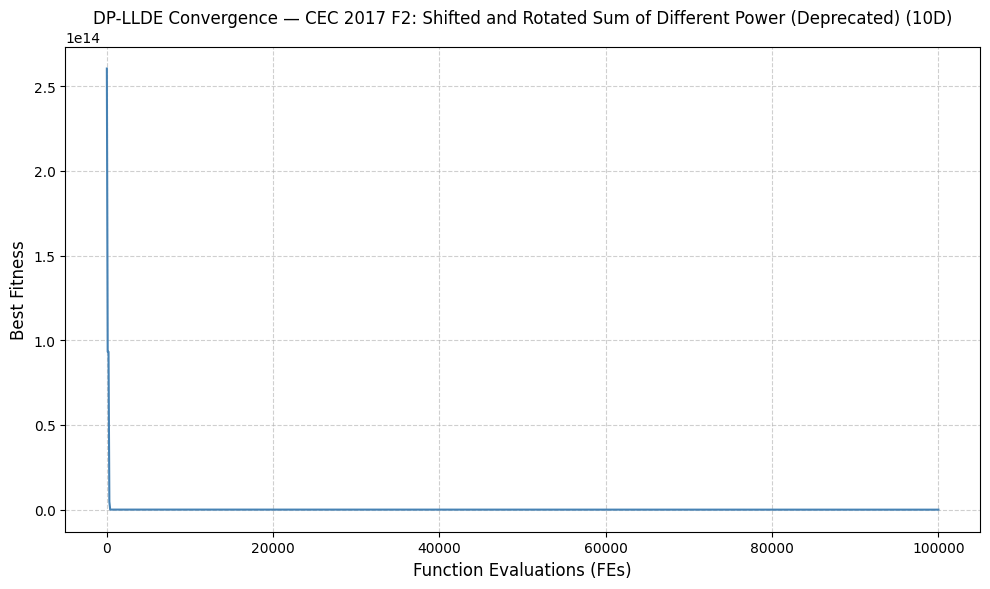

Graph saved as convergence_F2.png



In [11]:
# ============================================================
# F2 — Shifted and Rotated Sum of Different Power
# ============================================================
run_and_plot('F2', make_wrapper(simple.f2), 200.0, 'Shifted and Rotated Sum of Different Power (Deprecated)')

DP-LLDE on CEC 2017 F3 — Single Run
Function       : Shifted and Rotated Zakharov (10D)
Bounds         : [-100, 100]
Global optimum : 300.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.625937e+04
Generation   10: Best = 2.625937e+04  FES =   1100  μ_F = 0.565  μ_CR = 0.348
Generation   20: Best = 2.575657e+04  FES =   2100  μ_F = 0.662  μ_CR = 0.358
Generation   30: Best = 1.643475e+04  FES =   3100  μ_F = 0.740  μ_CR = 0.329
Generation   40: Best = 1.352076e+04  FES =   4100  μ_F = 0.770  μ_CR = 0.316
Generation   50: Best = 1.352076e+04  FES =   5100  μ_F = 0.828  μ_CR = 0.326
Generation   60: Best = 7.987234e+03  FES =   6100  μ_F = 0.824  μ_CR = 0.282
Generation   70: Best = 7.987234e+03  FES =   7100  μ_F = 0.812  μ_CR = 0.288
Generation   80: Best = 7.987234e+03  FES =   8100  μ_F = 0.813  μ_CR = 0.303
Generation   90: Best = 7.987234e+03  FES =   9100  μ_F = 0.818  μ_CR = 0.319
Generation  100: Best = 7.987234e+03  FES =  10100  

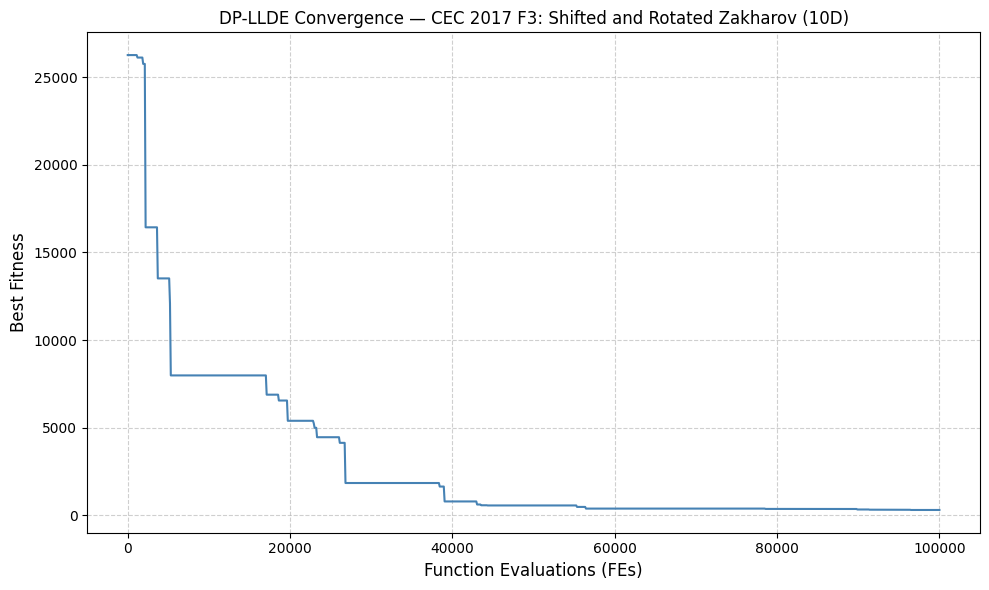

Graph saved as convergence_F3.png



In [12]:
# ============================================================
# F3 — Shifted and Rotated Zakharov
# ============================================================
run_and_plot('F3', make_wrapper(simple.f3), 300.0, 'Shifted and Rotated Zakharov')

## **6.2 Multimodal Functions (F4-F10)**

DP-LLDE on CEC 2017 F4 — Single Run
Function       : Shifted and Rotated Rosenbrock's (10D)
Bounds         : [-100, 100]
Global optimum : 400.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.004346e+03
Generation   10: Best = 5.016087e+02  FES =   1100  μ_F = 0.591  μ_CR = 0.352
Generation   20: Best = 4.334252e+02  FES =   2100  μ_F = 0.632  μ_CR = 0.358
Generation   30: Best = 4.122972e+02  FES =   3100  μ_F = 0.680  μ_CR = 0.366
Generation   40: Best = 4.090799e+02  FES =   4100  μ_F = 0.707  μ_CR = 0.362
Generation   50: Best = 4.077873e+02  FES =   5100  μ_F = 0.737  μ_CR = 0.361
Generation   60: Best = 4.073258e+02  FES =   6100  μ_F = 0.754  μ_CR = 0.366
Generation   70: Best = 4.070575e+02  FES =   7100  μ_F = 0.766  μ_CR = 0.387
Generation   80: Best = 4.067181e+02  FES =   8100  μ_F = 0.786  μ_CR = 0.385
Generation   90: Best = 4.063728e+02  FES =   9100  μ_F = 0.806  μ_CR = 0.410
Generation  100: Best = 4.062912e+02  FES =  101

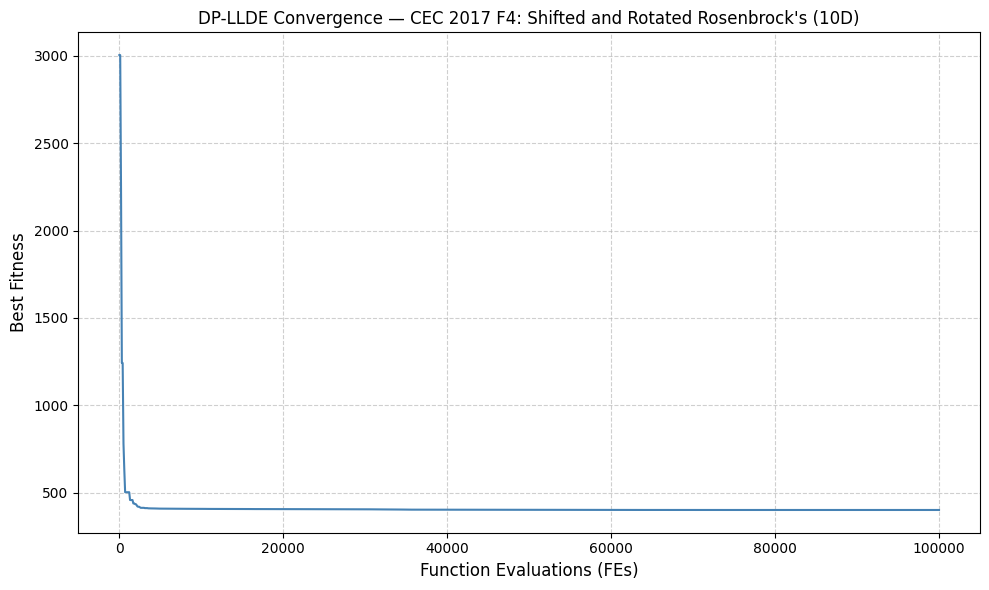

Graph saved as convergence_F4.png



In [13]:
# ============================================================
# F4 — Shifted and Rotated Rosenbrock
# ============================================================
run_and_plot('F4', make_wrapper(simple.f4), 400.0, "Shifted and Rotated Rosenbrock's")

DP-LLDE on CEC 2017 F5 — Single Run
Function       : Shifted and Rotated Rastrigin's (10D)
Bounds         : [-100, 100]
Global optimum : 500.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 6.377184e+02
Generation   10: Best = 5.718597e+02  FES =   1100  μ_F = 0.589  μ_CR = 0.354
Generation   20: Best = 5.444877e+02  FES =   2100  μ_F = 0.647  μ_CR = 0.353
Generation   30: Best = 5.444877e+02  FES =   3100  μ_F = 0.699  μ_CR = 0.325
Generation   40: Best = 5.444877e+02  FES =   4100  μ_F = 0.757  μ_CR = 0.297
Generation   50: Best = 5.444877e+02  FES =   5100  μ_F = 0.779  μ_CR = 0.267
Generation   60: Best = 5.444877e+02  FES =   6100  μ_F = 0.792  μ_CR = 0.236
Generation   70: Best = 5.319262e+02  FES =   7100  μ_F = 0.790  μ_CR = 0.197
Generation   80: Best = 5.319262e+02  FES =   8100  μ_F = 0.822  μ_CR = 0.197
Generation   90: Best = 5.300941e+02  FES =   9100  μ_F = 0.866  μ_CR = 0.161
Generation  100: Best = 5.222443e+02  FES =  1010

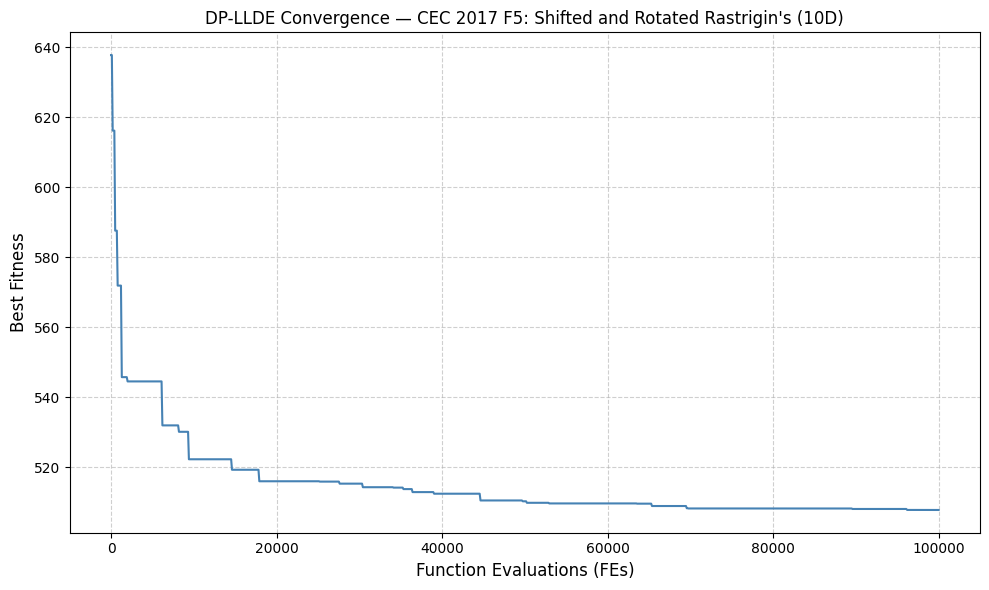

Graph saved as convergence_F5.png



In [14]:
# ============================================================
# F5 — Shifted and Rotated Rastrigin
# ============================================================
run_and_plot('F5', make_wrapper(simple.f5), 500.0, "Shifted and Rotated Rastrigin's")

DP-LLDE on CEC 2017 F6 — Single Run
Function       : Shifted and Rotated Schaffer's F7 (10D)
Bounds         : [-100, 100]
Global optimum : 600.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 7.140452e+02
Generation   10: Best = 6.329242e+02  FES =   1100  μ_F = 0.582  μ_CR = 0.352
Generation   20: Best = 6.217817e+02  FES =   2100  μ_F = 0.633  μ_CR = 0.354
Generation   30: Best = 6.141204e+02  FES =   3100  μ_F = 0.660  μ_CR = 0.352
Generation   40: Best = 6.083732e+02  FES =   4100  μ_F = 0.704  μ_CR = 0.344
Generation   50: Best = 6.059138e+02  FES =   5100  μ_F = 0.724  μ_CR = 0.348
Generation   60: Best = 6.046847e+02  FES =   6100  μ_F = 0.746  μ_CR = 0.352
Generation   70: Best = 6.032822e+02  FES =   7100  μ_F = 0.758  μ_CR = 0.353
Generation   80: Best = 6.018303e+02  FES =   8100  μ_F = 0.746  μ_CR = 0.356
Generation   90: Best = 6.011224e+02  FES =   9100  μ_F = 0.748  μ_CR = 0.363
Generation  100: Best = 6.009947e+02  FES =  10

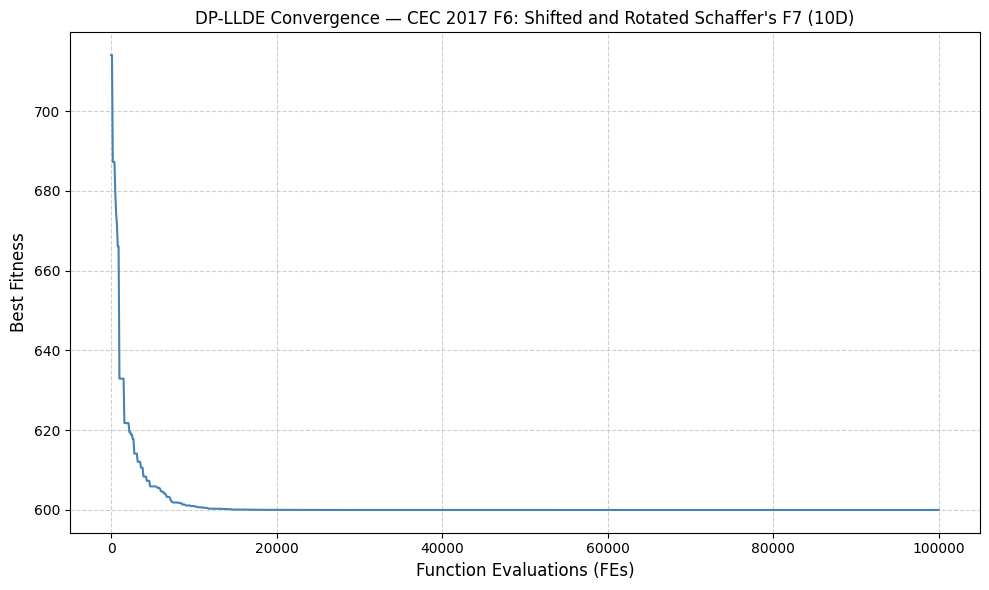

Graph saved as convergence_F6.png



In [15]:
# ============================================================
# F6 — Shifted and Rotated Schaffer's F7
# ============================================================
run_and_plot('F6', make_wrapper(simple.f6), 600.0, "Shifted and Rotated Schaffer's F7")

DP-LLDE on CEC 2017 F7 — Single Run
Function       : Shifted and Rotated Lunacek Bi-Rastrigin's (10D)
Bounds         : [-100, 100]
Global optimum : 700.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.202264e+03
Generation   10: Best = 8.489179e+02  FES =   1100  μ_F = 0.569  μ_CR = 0.355
Generation   20: Best = 7.968365e+02  FES =   2100  μ_F = 0.623  μ_CR = 0.361
Generation   30: Best = 7.663103e+02  FES =   3100  μ_F = 0.686  μ_CR = 0.344
Generation   40: Best = 7.559472e+02  FES =   4100  μ_F = 0.734  μ_CR = 0.324
Generation   50: Best = 7.559472e+02  FES =   5100  μ_F = 0.753  μ_CR = 0.296
Generation   60: Best = 7.494917e+02  FES =   6100  μ_F = 0.748  μ_CR = 0.272
Generation   70: Best = 7.457571e+02  FES =   7100  μ_F = 0.749  μ_CR = 0.223
Generation   80: Best = 7.349353e+02  FES =   8100  μ_F = 0.765  μ_CR = 0.195
Generation   90: Best = 7.349353e+02  FES =   9100  μ_F = 0.795  μ_CR = 0.157
Generation  100: Best = 7.349353e+02  

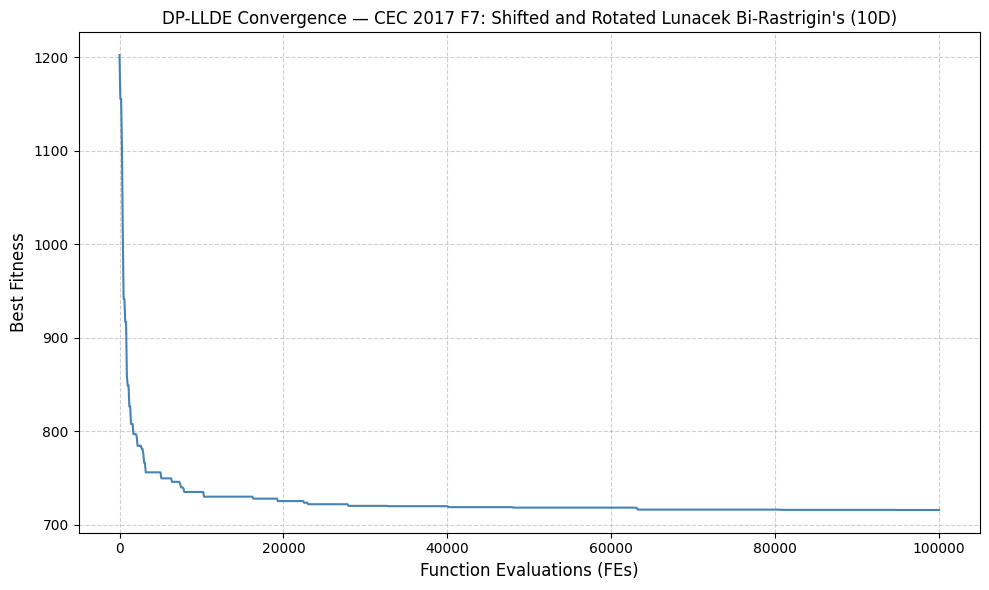

Graph saved as convergence_F7.png



In [16]:
# ============================================================
# F7 — Shifted and Rotated Lunacek Bi-Rastrigin
# ============================================================
run_and_plot('F7', make_wrapper(simple.f7), 700.0, "Shifted and Rotated Lunacek Bi-Rastrigin's")

DP-LLDE on CEC 2017 F8 — Single Run
Function       : Shifted and Rotated Non-Continuous Rastrigin's (10D)
Bounds         : [-100, 100]
Global optimum : 800.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 9.505966e+02
Generation   10: Best = 8.580610e+02  FES =   1100  μ_F = 0.592  μ_CR = 0.354
Generation   20: Best = 8.460823e+02  FES =   2100  μ_F = 0.623  μ_CR = 0.353
Generation   30: Best = 8.460823e+02  FES =   3100  μ_F = 0.663  μ_CR = 0.341
Generation   40: Best = 8.427672e+02  FES =   4100  μ_F = 0.724  μ_CR = 0.292
Generation   50: Best = 8.427672e+02  FES =   5100  μ_F = 0.741  μ_CR = 0.281
Generation   60: Best = 8.427672e+02  FES =   6100  μ_F = 0.746  μ_CR = 0.244
Generation   70: Best = 8.346868e+02  FES =   7100  μ_F = 0.760  μ_CR = 0.231
Generation   80: Best = 8.328655e+02  FES =   8100  μ_F = 0.795  μ_CR = 0.187
Generation   90: Best = 8.214897e+02  FES =   9100  μ_F = 0.809  μ_CR = 0.164
Generation  100: Best = 8.214897e+

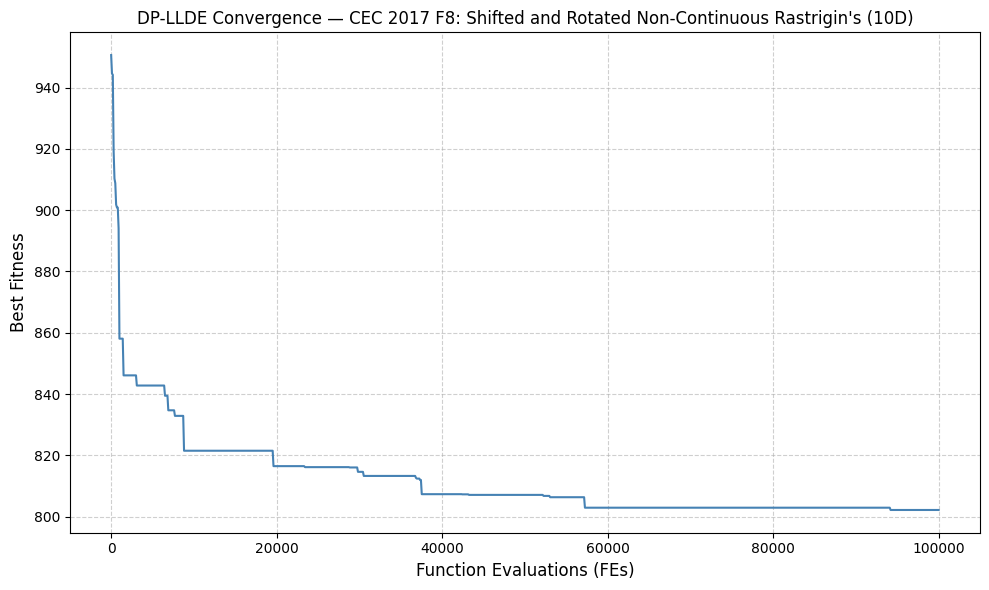

Graph saved as convergence_F8.png



In [17]:
# ============================================================
# F8 — Shifted and Rotated Non-Continuous Rastrigin
# ============================================================
run_and_plot('F8', make_wrapper(simple.f8), 800.0, "Shifted and Rotated Non-Continuous Rastrigin's")

DP-LLDE on CEC 2017 F9 — Single Run
Function       : Shifted and Rotated Levy (10D)
Bounds         : [-100, 100]
Global optimum : 900.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 6.112557e+03
Generation   10: Best = 1.826023e+03  FES =   1100  μ_F = 0.580  μ_CR = 0.351
Generation   20: Best = 1.208896e+03  FES =   2100  μ_F = 0.629  μ_CR = 0.351
Generation   30: Best = 1.111376e+03  FES =   3100  μ_F = 0.654  μ_CR = 0.355
Generation   40: Best = 9.289044e+02  FES =   4100  μ_F = 0.699  μ_CR = 0.359
Generation   50: Best = 9.289044e+02  FES =   5100  μ_F = 0.734  μ_CR = 0.363
Generation   60: Best = 9.146935e+02  FES =   6100  μ_F = 0.757  μ_CR = 0.352
Generation   70: Best = 9.071511e+02  FES =   7100  μ_F = 0.776  μ_CR = 0.367
Generation   80: Best = 9.019421e+02  FES =   8100  μ_F = 0.776  μ_CR = 0.369
Generation   90: Best = 9.010530e+02  FES =   9100  μ_F = 0.777  μ_CR = 0.379
Generation  100: Best = 9.003551e+02  FES =  10100  μ_F 

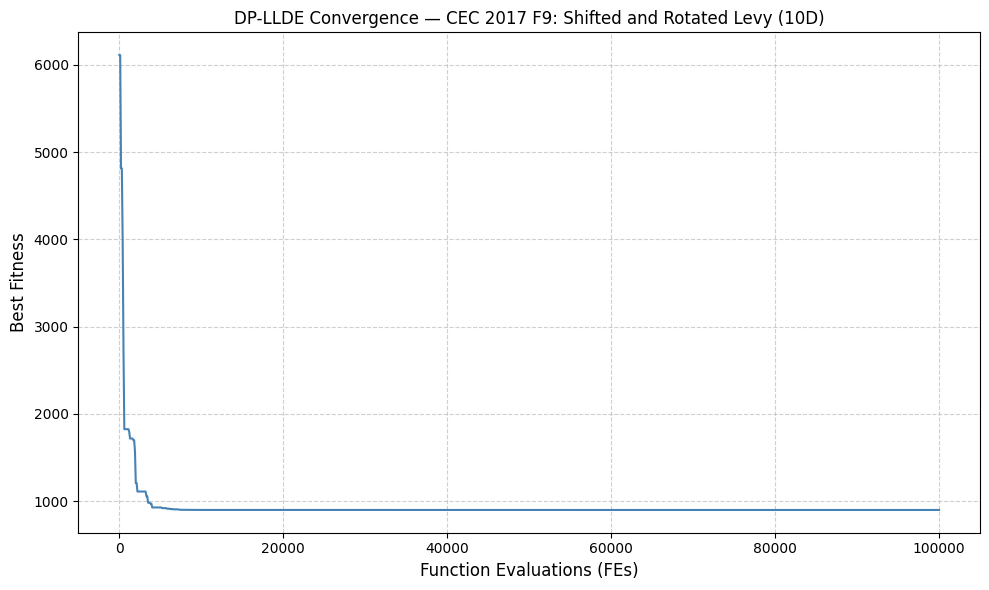

Graph saved as convergence_F9.png



In [18]:
# ============================================================
# F9 — Shifted and Rotated Levy
# ============================================================
run_and_plot('F9', make_wrapper(simple.f9), 900.0, 'Shifted and Rotated Levy')

DP-LLDE on CEC 2017 F10 — Single Run
Function       : Shifted and Rotated Schwefel's (10D)
Bounds         : [-100, 100]
Global optimum : 1000.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.749402e+03
Generation   10: Best = 3.175657e+03  FES =   1100  μ_F = 0.596  μ_CR = 0.346
Generation   20: Best = 2.947616e+03  FES =   2100  μ_F = 0.658  μ_CR = 0.306
Generation   30: Best = 2.913715e+03  FES =   3100  μ_F = 0.701  μ_CR = 0.290
Generation   40: Best = 2.742290e+03  FES =   4100  μ_F = 0.741  μ_CR = 0.271
Generation   50: Best = 2.585973e+03  FES =   5100  μ_F = 0.766  μ_CR = 0.235
Generation   60: Best = 2.513276e+03  FES =   6100  μ_F = 0.790  μ_CR = 0.223
Generation   70: Best = 2.364959e+03  FES =   7100  μ_F = 0.808  μ_CR = 0.204
Generation   80: Best = 2.288892e+03  FES =   8100  μ_F = 0.817  μ_CR = 0.160
Generation   90: Best = 2.288892e+03  FES =   9100  μ_F = 0.807  μ_CR = 0.143
Generation  100: Best = 2.288892e+03  FES =  101

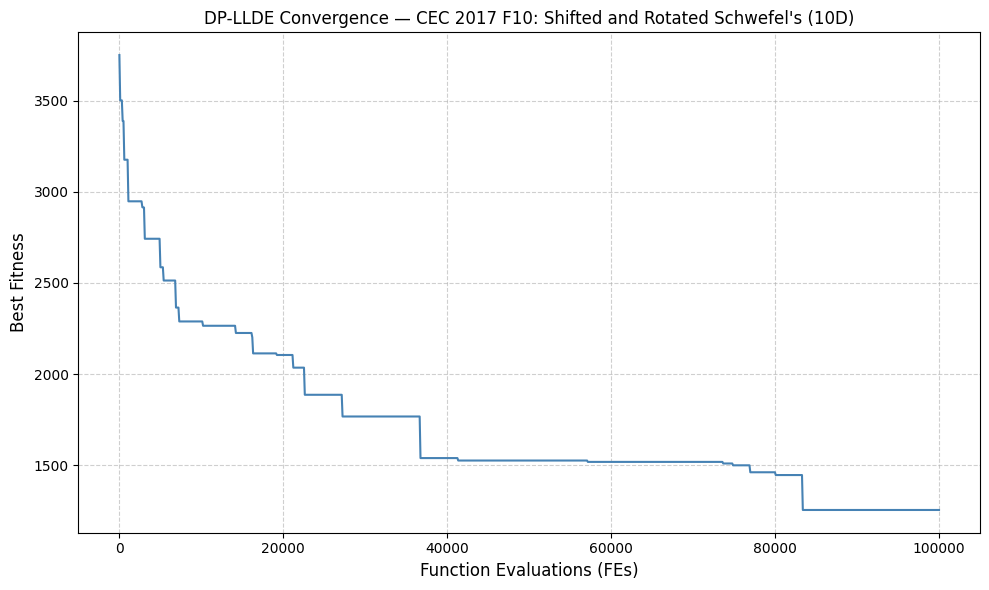

Graph saved as convergence_F10.png



In [19]:
# ============================================================
# F10 — Shifted and Rotated Schwefel
# ============================================================
run_and_plot('F10', make_wrapper(simple.f10), 1000.0, "Shifted and Rotated Schwefel's")

## **6.3 Hybrid Functions (F11-F20)**

DP-LLDE on CEC 2017 F11 — Single Run
Function       : Hybrid: Zakharov; Rosenbrock; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1100.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.292232e+04
Generation   10: Best = 1.980741e+03  FES =   1100  μ_F = 0.575  μ_CR = 0.350
Generation   20: Best = 1.320330e+03  FES =   2100  μ_F = 0.630  μ_CR = 0.361
Generation   30: Best = 1.189729e+03  FES =   3100  μ_F = 0.679  μ_CR = 0.370
Generation   40: Best = 1.149063e+03  FES =   4100  μ_F = 0.710  μ_CR = 0.369
Generation   50: Best = 1.119630e+03  FES =   5100  μ_F = 0.729  μ_CR = 0.371
Generation   60: Best = 1.119630e+03  FES =   6100  μ_F = 0.725  μ_CR = 0.371
Generation   70: Best = 1.118005e+03  FES =   7100  μ_F = 0.740  μ_CR = 0.373
Generation   80: Best = 1.114734e+03  FES =   8100  μ_F = 0.774  μ_CR = 0.372
Generation   90: Best = 1.110838e+03  FES =   9100  μ_F = 0.782  μ_CR = 0.348
Generation  100: Best = 1.110838e+03  F

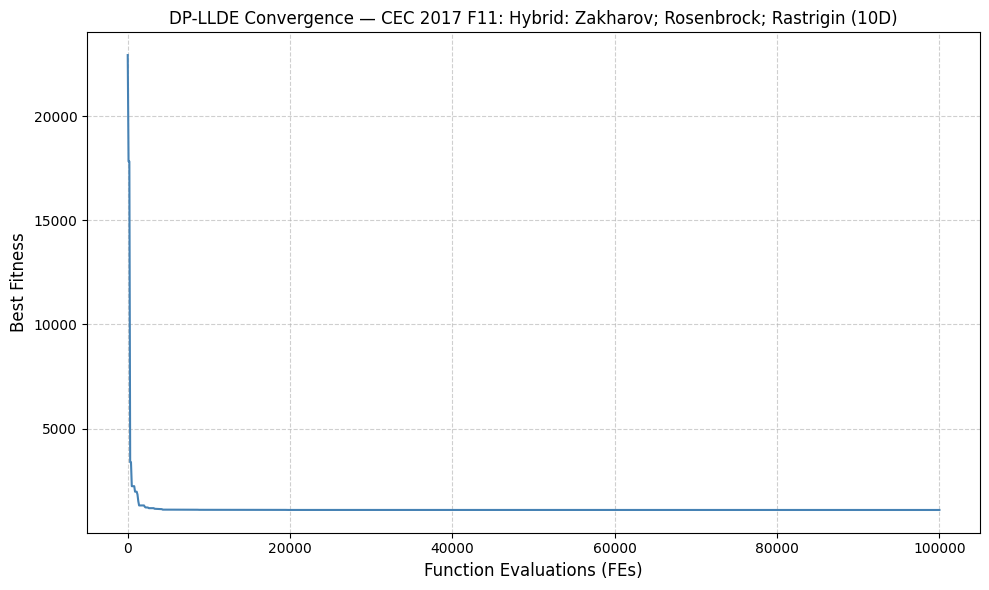

Graph saved as convergence_F11.png



In [20]:
# ============================================================
# F11 — Hybrid Function 1 (Zakharov; Rosenbrock; Rastrigin)
# ============================================================
run_and_plot('F11', make_wrapper(hybrid.f11), 1100.0, 'Hybrid: Zakharov; Rosenbrock; Rastrigin')

DP-LLDE on CEC 2017 F12 — Single Run
Function       : Hybrid: Elliptic; Schwefel; Bent Cigar (10D)
Bounds         : [-100, 100]
Global optimum : 1200.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 7.052719e+09
Generation   10: Best = 1.059061e+09  FES =   1100  μ_F = 0.565  μ_CR = 0.353
Generation   20: Best = 6.608687e+07  FES =   2100  μ_F = 0.631  μ_CR = 0.360
Generation   30: Best = 6.608687e+07  FES =   3100  μ_F = 0.679  μ_CR = 0.374
Generation   40: Best = 2.843259e+07  FES =   4100  μ_F = 0.703  μ_CR = 0.347
Generation   50: Best = 1.915405e+07  FES =   5100  μ_F = 0.726  μ_CR = 0.371
Generation   60: Best = 1.915405e+07  FES =   6100  μ_F = 0.725  μ_CR = 0.353
Generation   70: Best = 8.275568e+06  FES =   7100  μ_F = 0.759  μ_CR = 0.346
Generation   80: Best = 6.104102e+06  FES =   8100  μ_F = 0.795  μ_CR = 0.333
Generation   90: Best = 6.104102e+06  FES =   9100  μ_F = 0.793  μ_CR = 0.357
Generation  100: Best = 5.547196e+06  FE

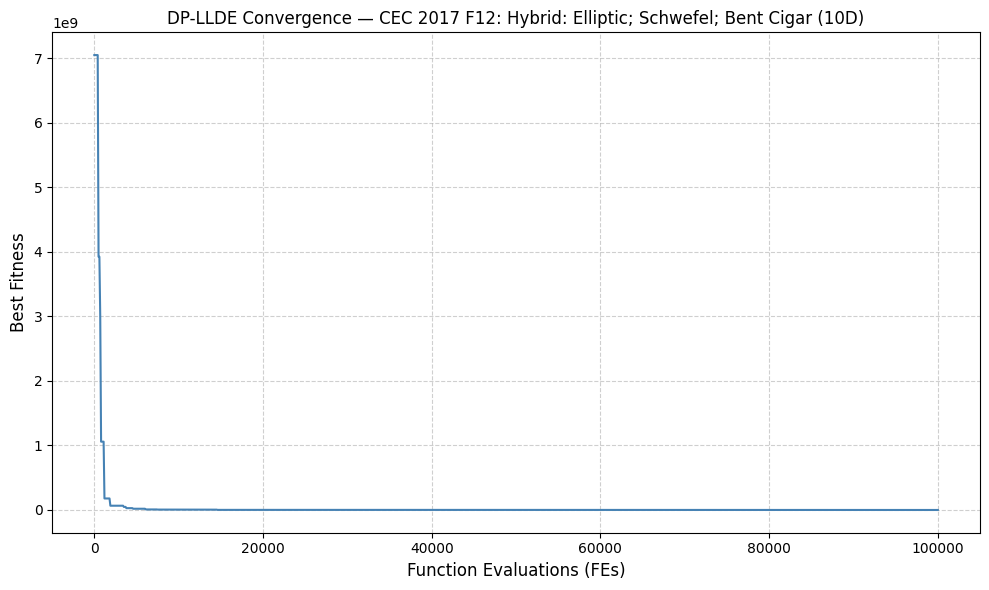

Graph saved as convergence_F12.png



In [21]:
# ============================================================
# F12 — Hybrid Function 2 (Elliptic; Schwefel; Bent Cigar)
# ============================================================
run_and_plot('F12', make_wrapper(hybrid.f12), 1200.0, 'Hybrid: Elliptic; Schwefel; Bent Cigar')

DP-LLDE on CEC 2017 F13 — Single Run
Function       : Hybrid: Bent Cigar; Rosenbrock; Bi-Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1300.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.212051e+09
Generation   10: Best = 6.999643e+06  FES =   1100  μ_F = 0.583  μ_CR = 0.356
Generation   20: Best = 3.196527e+05  FES =   2100  μ_F = 0.649  μ_CR = 0.359
Generation   30: Best = 2.666906e+04  FES =   3100  μ_F = 0.698  μ_CR = 0.368
Generation   40: Best = 2.655381e+04  FES =   4100  μ_F = 0.746  μ_CR = 0.355
Generation   50: Best = 1.512009e+04  FES =   5100  μ_F = 0.757  μ_CR = 0.348
Generation   60: Best = 1.508186e+04  FES =   6100  μ_F = 0.774  μ_CR = 0.335
Generation   70: Best = 9.382440e+03  FES =   7100  μ_F = 0.780  μ_CR = 0.359
Generation   80: Best = 5.834007e+03  FES =   8100  μ_F = 0.787  μ_CR = 0.372
Generation   90: Best = 2.566618e+03  FES =   9100  μ_F = 0.812  μ_CR = 0.390
Generation  100: Best = 1.661843e+

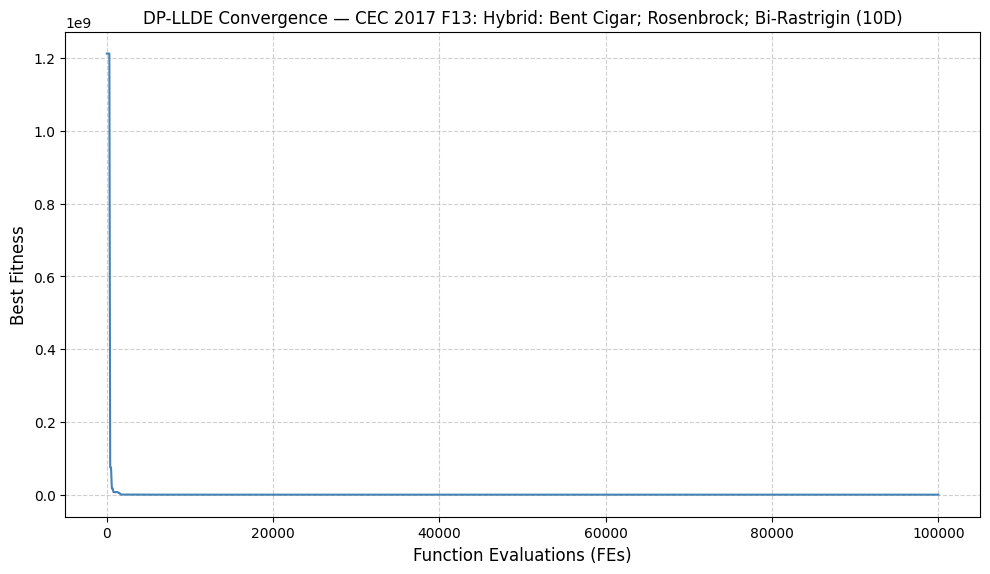

Graph saved as convergence_F13.png



In [22]:
# ============================================================
# F13 — Hybrid Function 3 (Bent Cigar; Rosenbrock; Bi-Rastrigin)
# ============================================================
run_and_plot('F13', make_wrapper(hybrid.f13), 1300.0, 'Hybrid: Bent Cigar; Rosenbrock; Bi-Rastrigin')

DP-LLDE on CEC 2017 F14 — Single Run
Function       : Hybrid: Elliptic; Ackley; Schaffer; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1400.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.917787e+04
Generation   10: Best = 1.274997e+04  FES =   1100  μ_F = 0.576  μ_CR = 0.352
Generation   20: Best = 1.924486e+03  FES =   2100  μ_F = 0.649  μ_CR = 0.370
Generation   30: Best = 1.851633e+03  FES =   3100  μ_F = 0.698  μ_CR = 0.373
Generation   40: Best = 1.494228e+03  FES =   4100  μ_F = 0.736  μ_CR = 0.354
Generation   50: Best = 1.482490e+03  FES =   5100  μ_F = 0.783  μ_CR = 0.354
Generation   60: Best = 1.480321e+03  FES =   6100  μ_F = 0.802  μ_CR = 0.357
Generation   70: Best = 1.469565e+03  FES =   7100  μ_F = 0.812  μ_CR = 0.369
Generation   80: Best = 1.457143e+03  FES =   8100  μ_F = 0.815  μ_CR = 0.380
Generation   90: Best = 1.447809e+03  FES =   9100  μ_F = 0.831  μ_CR = 0.369
Generation  100: Best = 1.447809e

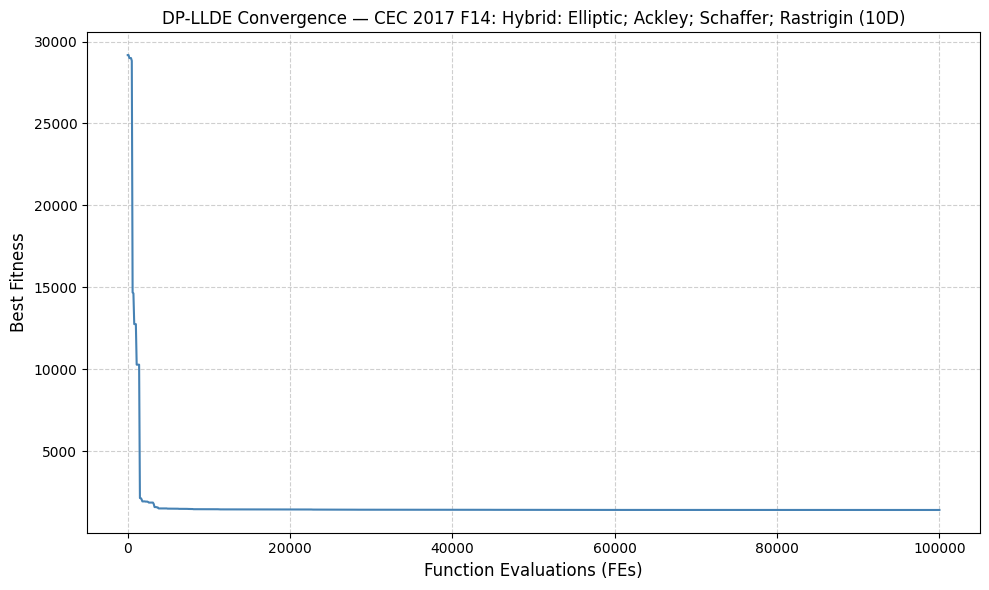

Graph saved as convergence_F14.png



In [23]:
# ============================================================
# F14 — Hybrid Function 4 (Elliptic; Ackley; Schaffer; Rastrigin)
# ============================================================
run_and_plot('F14', make_wrapper(hybrid.f14), 1400.0, 'Hybrid: Elliptic; Ackley; Schaffer; Rastrigin')

DP-LLDE on CEC 2017 F15 — Single Run
Function       : Hybrid: Bent Cigar; HGBat; Rastrigin; Rosenbrock (10D)
Bounds         : [-100, 100]
Global optimum : 1500.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.114909e+07
Generation   10: Best = 1.623632e+04  FES =   1100  μ_F = 0.592  μ_CR = 0.353
Generation   20: Best = 1.005621e+04  FES =   2100  μ_F = 0.655  μ_CR = 0.365
Generation   30: Best = 3.234705e+03  FES =   3100  μ_F = 0.711  μ_CR = 0.380
Generation   40: Best = 2.745474e+03  FES =   4100  μ_F = 0.758  μ_CR = 0.383
Generation   50: Best = 1.885532e+03  FES =   5100  μ_F = 0.791  μ_CR = 0.396
Generation   60: Best = 1.604902e+03  FES =   6100  μ_F = 0.811  μ_CR = 0.398
Generation   70: Best = 1.584215e+03  FES =   7100  μ_F = 0.827  μ_CR = 0.398
Generation   80: Best = 1.543533e+03  FES =   8100  μ_F = 0.822  μ_CR = 0.408
Generation   90: Best = 1.528394e+03  FES =   9100  μ_F = 0.835  μ_CR = 0.423
Generation  100: Best = 1.5227

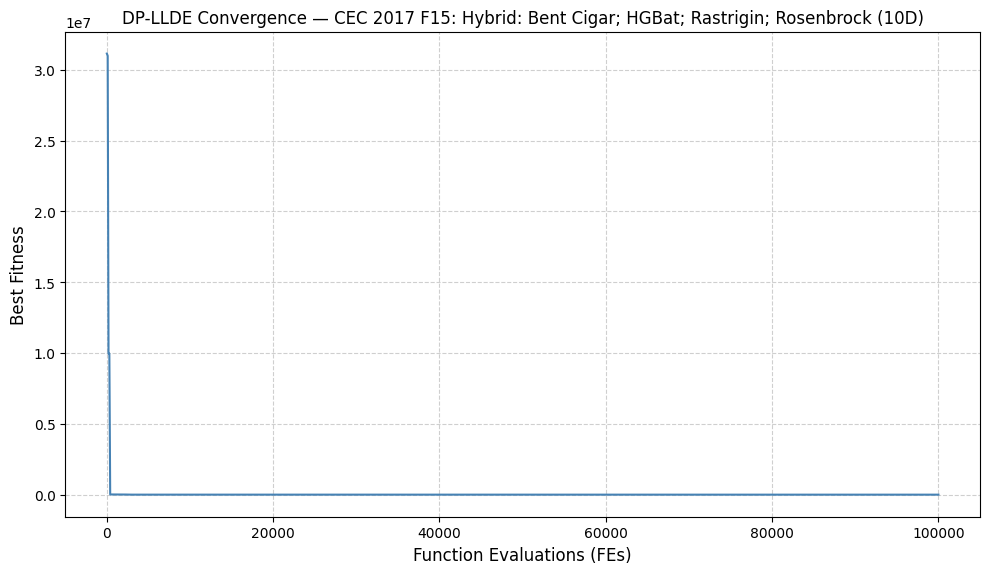

Graph saved as convergence_F15.png



In [24]:
# ============================================================
# F15 — Hybrid Function 5 (Bent Cigar; HGBat; Rastrigin; Rosenbrock)
# ============================================================
run_and_plot('F15', make_wrapper(hybrid.f15), 1500.0, 'Hybrid: Bent Cigar; HGBat; Rastrigin; Rosenbrock')

DP-LLDE on CEC 2017 F16 — Single Run
Function       : Hybrid: Schaffer; HGBat; Rosenbrock; Schwefel (10D)
Bounds         : [-100, 100]
Global optimum : 1600.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.512498e+03
Generation   10: Best = 2.161482e+03  FES =   1100  μ_F = 0.591  μ_CR = 0.354
Generation   20: Best = 1.819270e+03  FES =   2100  μ_F = 0.668  μ_CR = 0.351
Generation   30: Best = 1.816277e+03  FES =   3100  μ_F = 0.724  μ_CR = 0.349
Generation   40: Best = 1.698526e+03  FES =   4100  μ_F = 0.777  μ_CR = 0.317
Generation   50: Best = 1.680387e+03  FES =   5100  μ_F = 0.822  μ_CR = 0.298
Generation   60: Best = 1.668786e+03  FES =   6100  μ_F = 0.798  μ_CR = 0.273
Generation   70: Best = 1.668786e+03  FES =   7100  μ_F = 0.810  μ_CR = 0.243
Generation   80: Best = 1.643801e+03  FES =   8100  μ_F = 0.832  μ_CR = 0.205
Generation   90: Best = 1.643728e+03  FES =   9100  μ_F = 0.858  μ_CR = 0.179
Generation  100: Best = 1.636484e

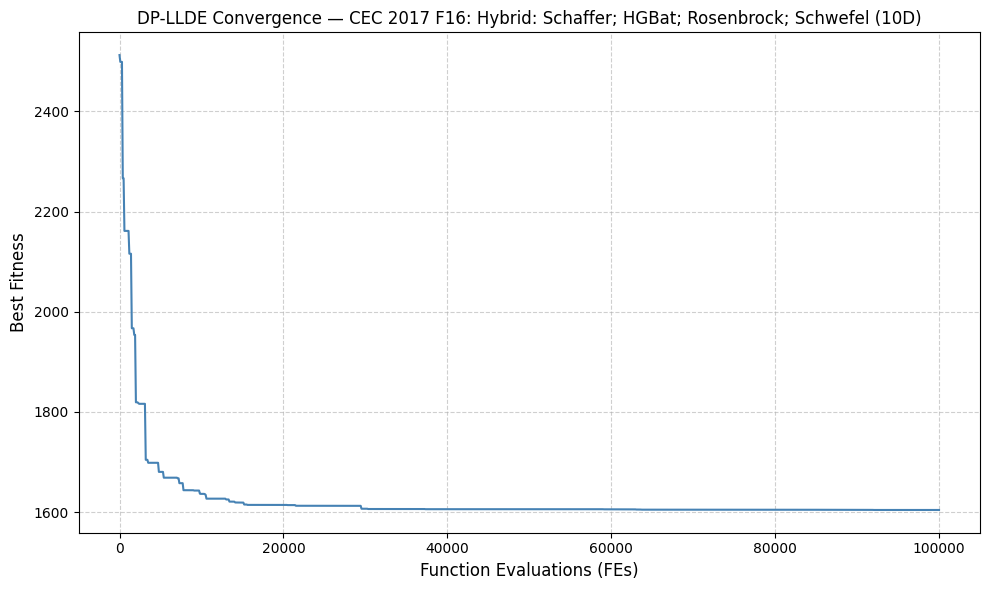

Graph saved as convergence_F16.png



In [25]:
# ============================================================
# F16 — Hybrid Function 6 (Schaffer; HGBat; Rosenbrock; Schwefel)
# ============================================================
run_and_plot('F16', make_wrapper(hybrid.f16), 1600.0, 'Hybrid: Schaffer; HGBat; Rosenbrock; Schwefel')

DP-LLDE on CEC 2017 F17 — Single Run
Function       : Hybrid: Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1700.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.471803e+03
Generation   10: Best = 1.953086e+03  FES =   1100  μ_F = 0.585  μ_CR = 0.351
Generation   20: Best = 1.776588e+03  FES =   2100  μ_F = 0.642  μ_CR = 0.335
Generation   30: Best = 1.764218e+03  FES =   3100  μ_F = 0.680  μ_CR = 0.326
Generation   40: Best = 1.753302e+03  FES =   4100  μ_F = 0.728  μ_CR = 0.294
Generation   50: Best = 1.753302e+03  FES =   5100  μ_F = 0.745  μ_CR = 0.273
Generation   60: Best = 1.753302e+03  FES =   6100  μ_F = 0.749  μ_CR = 0.250
Generation   70: Best = 1.742853e+03  FES =   7100  μ_F = 0.768  μ_CR = 0.230
Generation   80: Best = 1.733781e+03  FES =   8100  μ_F = 0.802  μ_CR = 0.203
Generation   90: Best = 1.733781e+03  FES =   9100  μ_F = 0.810  μ_CR = 0.183
Generation  

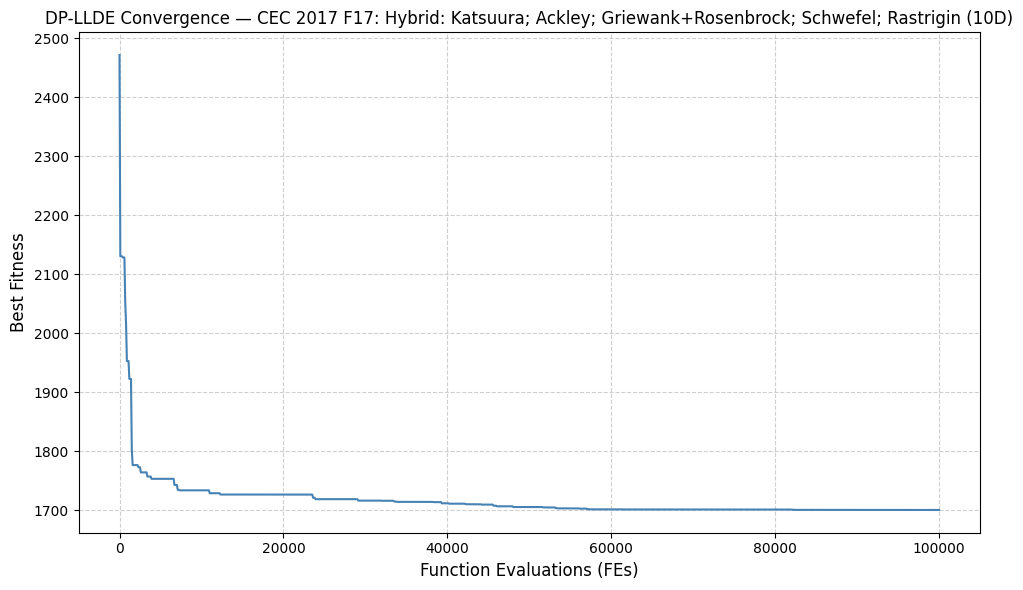

Graph saved as convergence_F17.png



In [26]:
# ============================================================
# F17 — Hybrid Function 7 (Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin)
# ============================================================
run_and_plot('F17', make_wrapper(hybrid.f17), 1700.0, 'Hybrid: Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin')

DP-LLDE on CEC 2017 F18 — Single Run
Function       : Hybrid: Elliptic; Ackley; Rastrigin; HGBat; Discus (10D)
Bounds         : [-100, 100]
Global optimum : 1800.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 6.135676e+08
Generation   10: Best = 4.006051e+06  FES =   1100  μ_F = 0.588  μ_CR = 0.353
Generation   20: Best = 1.066501e+05  FES =   2100  μ_F = 0.659  μ_CR = 0.361
Generation   30: Best = 5.583760e+04  FES =   3100  μ_F = 0.698  μ_CR = 0.361
Generation   40: Best = 5.582227e+04  FES =   4100  μ_F = 0.750  μ_CR = 0.351
Generation   50: Best = 3.463127e+04  FES =   5100  μ_F = 0.787  μ_CR = 0.354
Generation   60: Best = 3.363763e+04  FES =   6100  μ_F = 0.797  μ_CR = 0.358
Generation   70: Best = 3.363763e+04  FES =   7100  μ_F = 0.833  μ_CR = 0.348
Generation   80: Best = 3.104436e+04  FES =   8100  μ_F = 0.850  μ_CR = 0.337
Generation   90: Best = 2.949859e+04  FES =   9100  μ_F = 0.844  μ_CR = 0.335
Generation  100: Best = 2.84

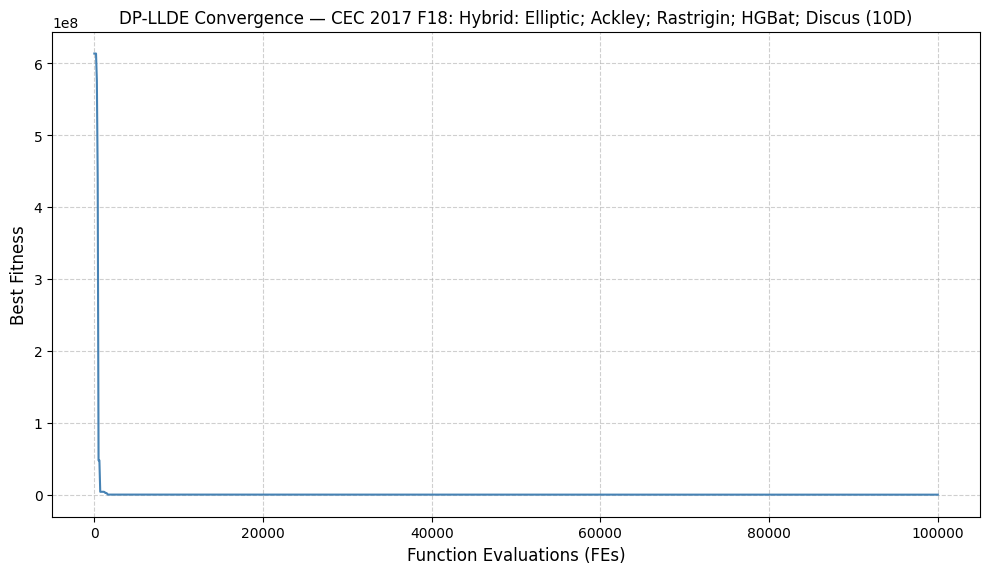

Graph saved as convergence_F18.png



In [27]:
# ============================================================
# F18 — Hybrid Function 8 (Elliptic; Ackley; Rastrigin; HGBat; Discus)
# ============================================================
run_and_plot('F18', make_wrapper(hybrid.f18), 1800.0, 'Hybrid: Elliptic; Ackley; Rastrigin; HGBat; Discus')

DP-LLDE on CEC 2017 F19 — Single Run
Function       : Hybrid: Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 1900.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.530389e+08
Generation   10: Best = 1.269618e+05  FES =   1100  μ_F = 0.593  μ_CR = 0.352
Generation   20: Best = 7.732173e+03  FES =   2100  μ_F = 0.655  μ_CR = 0.358
Generation   30: Best = 5.115634e+03  FES =   3100  μ_F = 0.713  μ_CR = 0.370
Generation   40: Best = 2.245612e+03  FES =   4100  μ_F = 0.752  μ_CR = 0.360
Generation   50: Best = 2.054358e+03  FES =   5100  μ_F = 0.788  μ_CR = 0.363
Generation   60: Best = 1.954333e+03  FES =   6100  μ_F = 0.807  μ_CR = 0.360
Generation   70: Best = 1.927934e+03  FES =   7100  μ_F = 0.829  μ_CR = 0.362
Generation   80: Best = 1.924950e+03  FES =   8100  μ_F = 0.843  μ_CR = 0.356
Generation   90: Best = 1.917941e+03  FES =   9100  μ_F = 0.835  μ_CR = 0.369
Gener

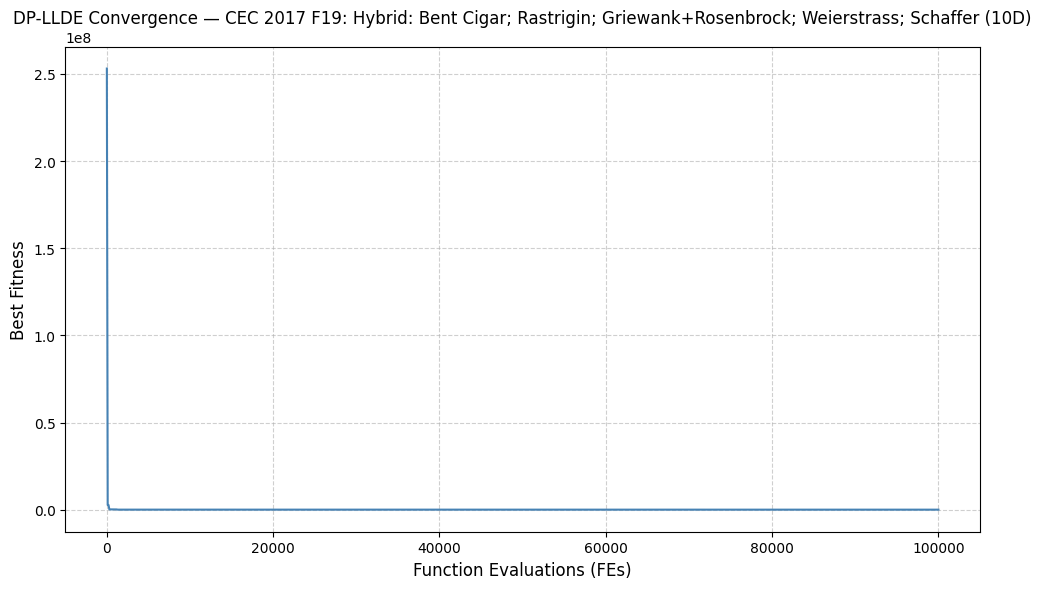

Graph saved as convergence_F19.png



In [28]:
# ============================================================
# F19 — Hybrid Function 9 (Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer)
# ============================================================
run_and_plot('F19', make_wrapper(hybrid.f19), 1900.0, 'Hybrid: Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer')

DP-LLDE on CEC 2017 F20 — Single Run
Function       : Hybrid: HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 2000.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.391561e+03
Generation   10: Best = 2.182241e+03  FES =   1100  μ_F = 0.580  μ_CR = 0.341
Generation   20: Best = 2.158179e+03  FES =   2100  μ_F = 0.642  μ_CR = 0.332
Generation   30: Best = 2.097516e+03  FES =   3100  μ_F = 0.694  μ_CR = 0.335
Generation   40: Best = 2.074059e+03  FES =   4100  μ_F = 0.723  μ_CR = 0.308
Generation   50: Best = 2.072007e+03  FES =   5100  μ_F = 0.769  μ_CR = 0.290
Generation   60: Best = 2.054131e+03  FES =   6100  μ_F = 0.773  μ_CR = 0.267
Generation   70: Best = 2.050249e+03  FES =   7100  μ_F = 0.799  μ_CR = 0.256
Generation   80: Best = 2.041765e+03  FES =   8100  μ_F = 0.814  μ_CR = 0.232
Generation   90: Best = 2.036352e+03  FES =   9100  μ_F = 0.822  μ_CR = 0.208
Generation  1

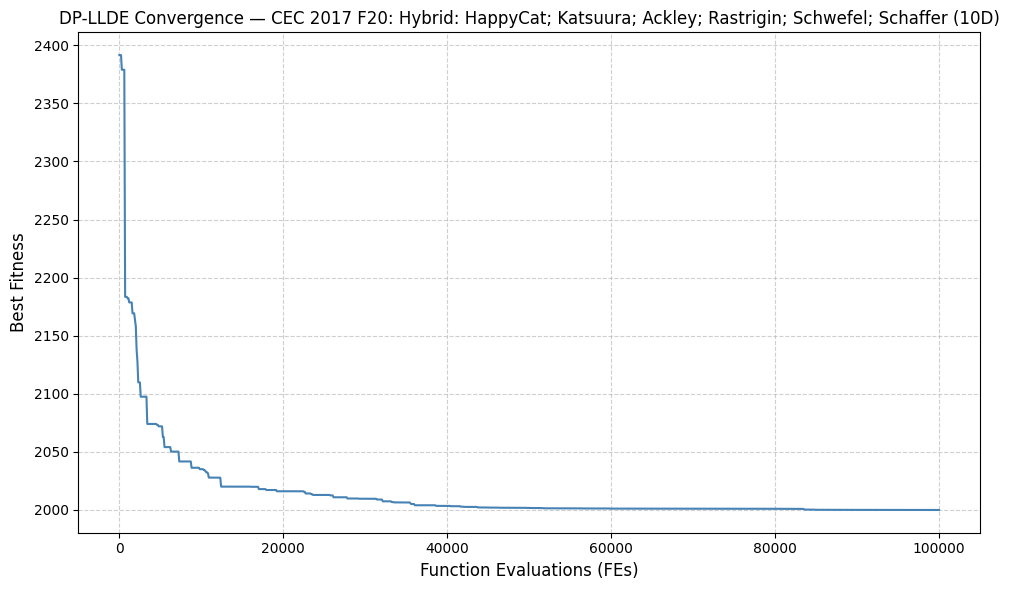

Graph saved as convergence_F20.png



In [29]:
# ============================================================
# F20 — Hybrid Function 10 (HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer)
# ============================================================
run_and_plot('F20', make_wrapper(hybrid.f20), 2000.0, 'Hybrid: HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer')

## **6.4 Composite Functions (F21-F30)**

DP-LLDE on CEC 2017 F21 — Single Run
Function       : Composition: Rosenbrock; Elliptic; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2100.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.446690e+03
Generation   10: Best = 2.349057e+03  FES =   1100  μ_F = 0.579  μ_CR = 0.349
Generation   20: Best = 2.349057e+03  FES =   2100  μ_F = 0.644  μ_CR = 0.352
Generation   30: Best = 2.349057e+03  FES =   3100  μ_F = 0.666  μ_CR = 0.334
Generation   40: Best = 2.344305e+03  FES =   4100  μ_F = 0.751  μ_CR = 0.316
Generation   50: Best = 2.344305e+03  FES =   5100  μ_F = 0.763  μ_CR = 0.303
Generation   60: Best = 2.336191e+03  FES =   6100  μ_F = 0.748  μ_CR = 0.268
Generation   70: Best = 2.336191e+03  FES =   7100  μ_F = 0.740  μ_CR = 0.235
Generation   80: Best = 2.336191e+03  FES =   8100  μ_F = 0.763  μ_CR = 0.205
Generation   90: Best = 2.336191e+03  FES =   9100  μ_F = 0.760  μ_CR = 0.161
Generation  100: Best = 2.336191e+

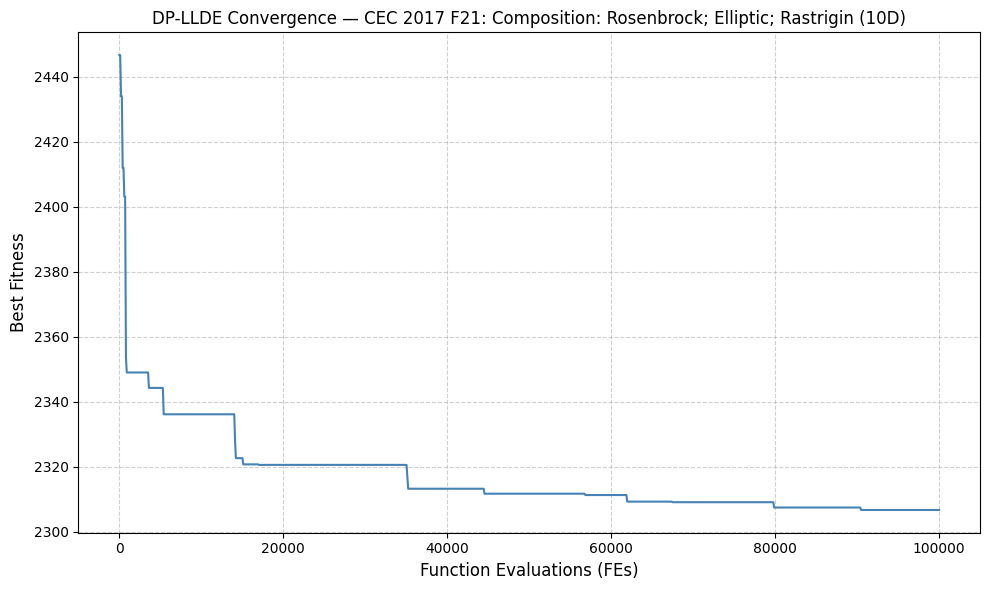

Graph saved as convergence_F21.png



In [30]:
# ============================================================
# F21 — Composition Function 1 (Rosenbrock; Elliptic; Rastrigin)
# ============================================================
run_and_plot('F21', make_wrapper(composition.f21), 2100.0, 'Composition: Rosenbrock; Elliptic; Rastrigin')

DP-LLDE on CEC 2017 F22 — Single Run
Function       : Composition: Rastrigin; Griewank; Schwefel (10D)
Bounds         : [-100, 100]
Global optimum : 2200.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.528003e+03
Generation   10: Best = 2.578427e+03  FES =   1100  μ_F = 0.574  μ_CR = 0.351
Generation   20: Best = 2.370023e+03  FES =   2100  μ_F = 0.620  μ_CR = 0.356
Generation   30: Best = 2.321176e+03  FES =   3100  μ_F = 0.661  μ_CR = 0.365
Generation   40: Best = 2.311879e+03  FES =   4100  μ_F = 0.704  μ_CR = 0.363
Generation   50: Best = 2.307778e+03  FES =   5100  μ_F = 0.741  μ_CR = 0.366
Generation   60: Best = 2.305415e+03  FES =   6100  μ_F = 0.761  μ_CR = 0.362
Generation   70: Best = 2.303457e+03  FES =   7100  μ_F = 0.765  μ_CR = 0.357
Generation   80: Best = 2.303224e+03  FES =   8100  μ_F = 0.762  μ_CR = 0.362
Generation   90: Best = 2.303224e+03  FES =   9100  μ_F = 0.790  μ_CR = 0.354
Generation  100: Best = 2.303091e+03

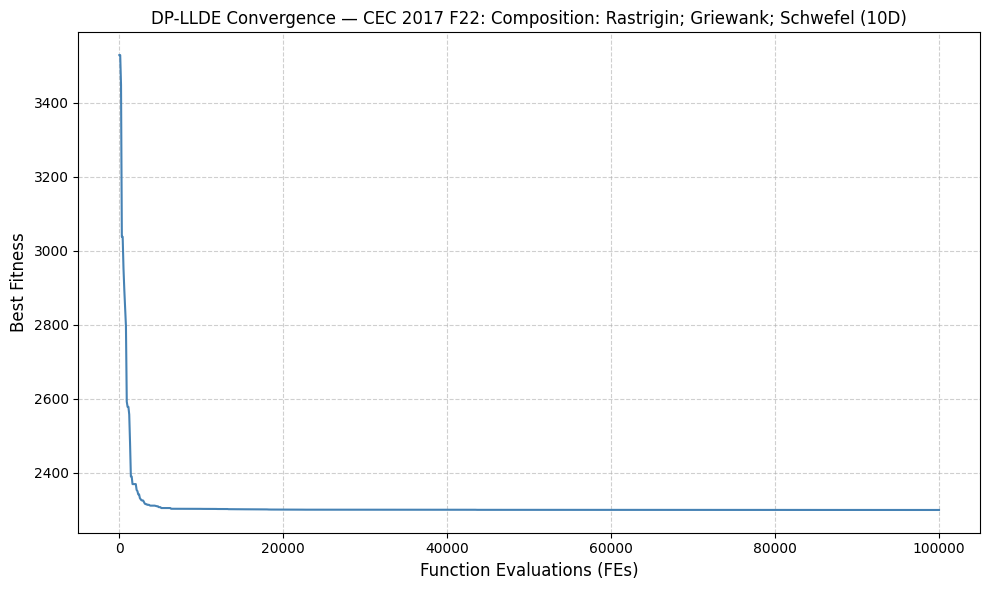

Graph saved as convergence_F22.png



In [31]:
# ============================================================
# F22 — Composition Function 2 (Rastrigin; Griewank; Schwefel)
# ============================================================
run_and_plot('F22', make_wrapper(composition.f22), 2200.0, 'Composition: Rastrigin; Griewank; Schwefel')

DP-LLDE on CEC 2017 F23 — Single Run
Function       : Composition: Rosenbrock; Ackley; Schwefel; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2300.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.773921e+03
Generation   10: Best = 2.683384e+03  FES =   1100  μ_F = 0.597  μ_CR = 0.355
Generation   20: Best = 2.645769e+03  FES =   2100  μ_F = 0.666  μ_CR = 0.352
Generation   30: Best = 2.645769e+03  FES =   3100  μ_F = 0.738  μ_CR = 0.342
Generation   40: Best = 2.631283e+03  FES =   4100  μ_F = 0.784  μ_CR = 0.300
Generation   50: Best = 2.631283e+03  FES =   5100  μ_F = 0.832  μ_CR = 0.269
Generation   60: Best = 2.631283e+03  FES =   6100  μ_F = 0.828  μ_CR = 0.224
Generation   70: Best = 2.631283e+03  FES =   7100  μ_F = 0.825  μ_CR = 0.237
Generation   80: Best = 2.631283e+03  FES =   8100  μ_F = 0.844  μ_CR = 0.192
Generation   90: Best = 2.629149e+03  FES =   9100  μ_F = 0.859  μ_CR = 0.148
Generation  100: Best = 2.

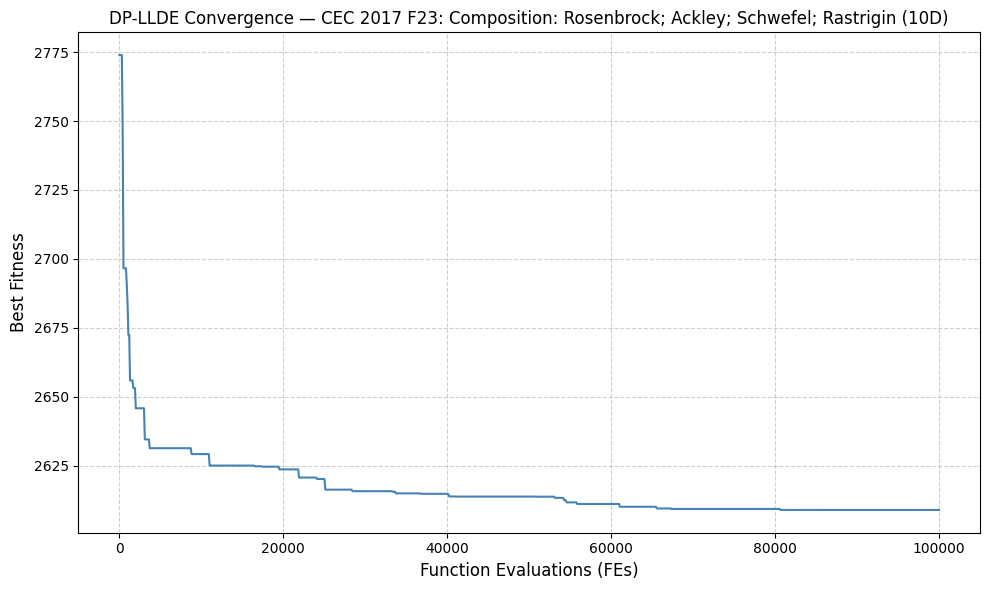

Graph saved as convergence_F23.png



In [32]:
# ============================================================
# F23 — Composition Function 3 (Rosenbrock; Ackley; Schwefel; Rastrigin)
# ============================================================
run_and_plot('F23', make_wrapper(composition.f23), 2300.0, 'Composition: Rosenbrock; Ackley; Schwefel; Rastrigin')

DP-LLDE on CEC 2017 F24 — Single Run
Function       : Composition: Ackley; Elliptic; Griewank; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2400.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.997998e+03
Generation   10: Best = 2.798695e+03  FES =   1100  μ_F = 0.601  μ_CR = 0.349
Generation   20: Best = 2.784612e+03  FES =   2100  μ_F = 0.656  μ_CR = 0.356
Generation   30: Best = 2.784204e+03  FES =   3100  μ_F = 0.685  μ_CR = 0.366
Generation   40: Best = 2.773931e+03  FES =   4100  μ_F = 0.743  μ_CR = 0.349
Generation   50: Best = 2.767987e+03  FES =   5100  μ_F = 0.765  μ_CR = 0.315
Generation   60: Best = 2.761958e+03  FES =   6100  μ_F = 0.768  μ_CR = 0.273
Generation   70: Best = 2.761958e+03  FES =   7100  μ_F = 0.812  μ_CR = 0.240
Generation   80: Best = 2.761958e+03  FES =   8100  μ_F = 0.806  μ_CR = 0.201
Generation   90: Best = 2.761958e+03  FES =   9100  μ_F = 0.706  μ_CR = 0.216
Generation  100: Best = 2.75

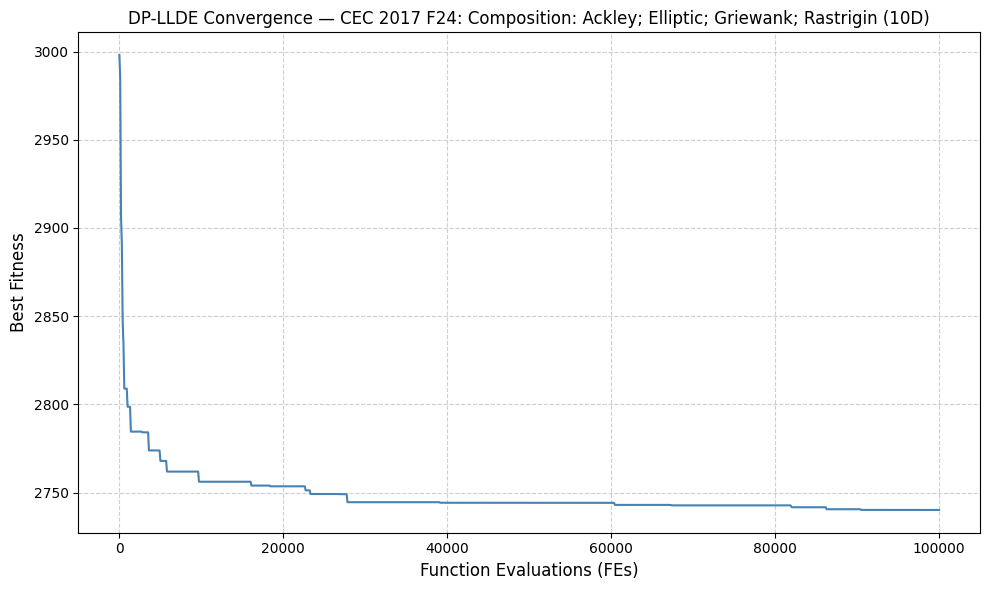

Graph saved as convergence_F24.png



In [33]:
# ============================================================
# F24 — Composition Function 4 (Ackley; Elliptic; Griewank; Rastrigin)
# ============================================================
run_and_plot('F24', make_wrapper(composition.f24), 2400.0, 'Composition: Ackley; Elliptic; Griewank; Rastrigin')

DP-LLDE on CEC 2017 F25 — Single Run
Function       : Composition: Rastrigin; HappyCat; Ackley; Discus; Rosenbrock (10D)
Bounds         : [-100, 100]
Global optimum : 2500.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 4.081798e+03
Generation   10: Best = 3.008847e+03  FES =   1100  μ_F = 0.587  μ_CR = 0.359
Generation   20: Best = 2.985759e+03  FES =   2100  μ_F = 0.641  μ_CR = 0.361
Generation   30: Best = 2.960889e+03  FES =   3100  μ_F = 0.673  μ_CR = 0.364
Generation   40: Best = 2.954670e+03  FES =   4100  μ_F = 0.689  μ_CR = 0.362
Generation   50: Best = 2.953379e+03  FES =   5100  μ_F = 0.724  μ_CR = 0.362
Generation   60: Best = 2.952419e+03  FES =   6100  μ_F = 0.743  μ_CR = 0.361
Generation   70: Best = 2.951961e+03  FES =   7100  μ_F = 0.751  μ_CR = 0.370
Generation   80: Best = 2.951506e+03  FES =   8100  μ_F = 0.749  μ_CR = 0.367
Generation   90: Best = 2.950771e+03  FES =   9100  μ_F = 0.753  μ_CR = 0.396
Generation  100: B

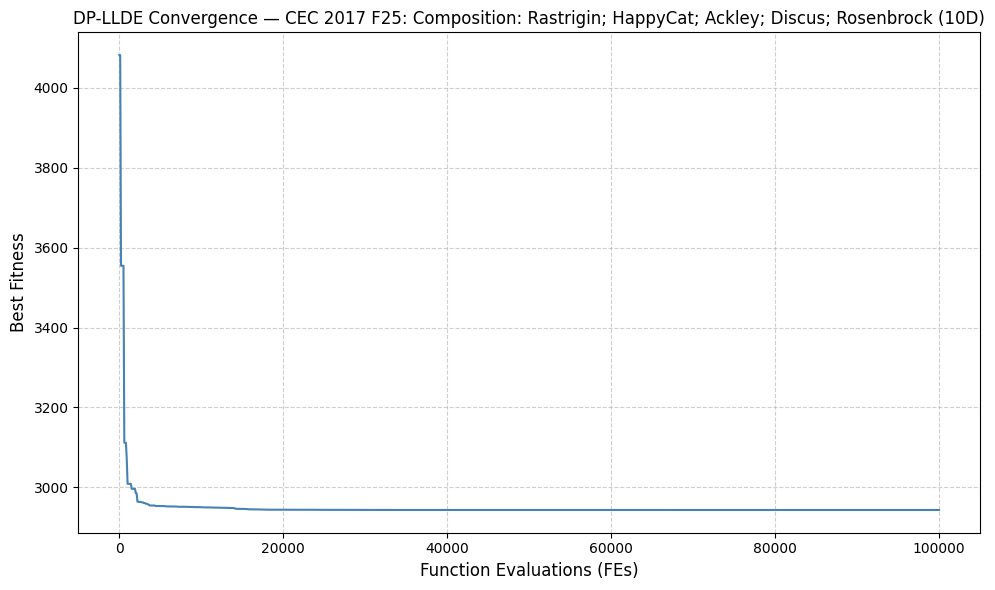

Graph saved as convergence_F25.png



In [34]:
# ============================================================
# F25 — Composition Function 5 (Rastrigin; HappyCat; Ackley; Discus; Rosenbrock)
# ============================================================
run_and_plot('F25', make_wrapper(composition.f25), 2500.0, 'Composition: Rastrigin; HappyCat; Ackley; Discus; Rosenbrock')

DP-LLDE on CEC 2017 F26 — Single Run
Function       : Composition: Schaffer; Schwefel; Griewank; Rosenbrock; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2600.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 4.061684e+03
Generation   10: Best = 3.370966e+03  FES =   1100  μ_F = 0.574  μ_CR = 0.351
Generation   20: Best = 3.255291e+03  FES =   2100  μ_F = 0.626  μ_CR = 0.352
Generation   30: Best = 3.074601e+03  FES =   3100  μ_F = 0.672  μ_CR = 0.367
Generation   40: Best = 3.012500e+03  FES =   4100  μ_F = 0.694  μ_CR = 0.359
Generation   50: Best = 3.002179e+03  FES =   5100  μ_F = 0.732  μ_CR = 0.370
Generation   60: Best = 2.972709e+03  FES =   6100  μ_F = 0.760  μ_CR = 0.369
Generation   70: Best = 2.959383e+03  FES =   7100  μ_F = 0.768  μ_CR = 0.371
Generation   80: Best = 2.954255e+03  FES =   8100  μ_F = 0.774  μ_CR = 0.371
Generation   90: Best = 2.952082e+03  FES =   9100  μ_F = 0.778  μ_CR = 0.373
Generation  10

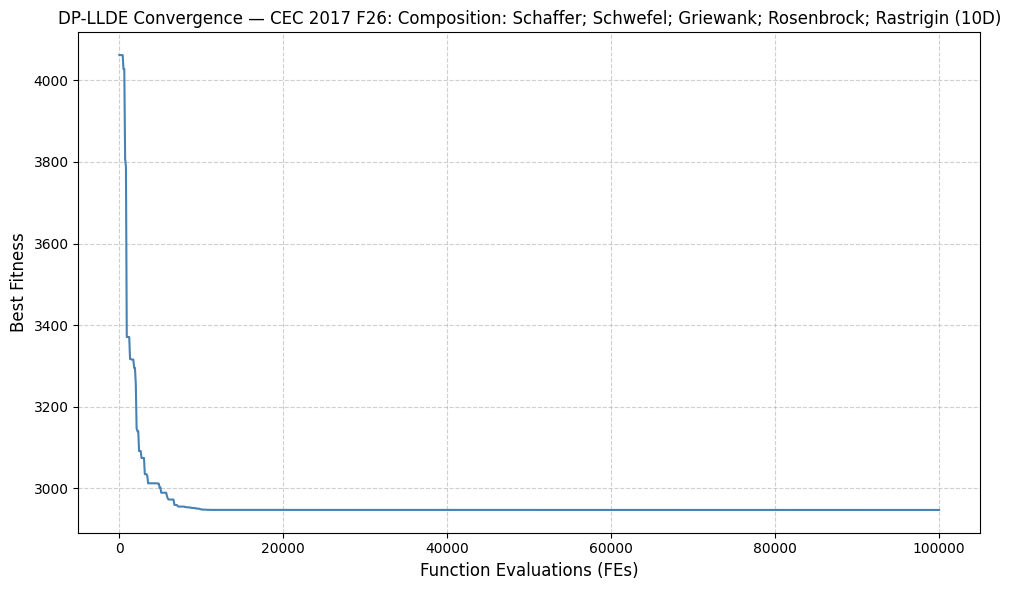

Graph saved as convergence_F26.png



In [35]:
# ============================================================
# F26 — Composition Function 6 (Schaffer; Schwefel; Griewank; Rosenbrock; Rastrigin)
# ============================================================
run_and_plot('F26', make_wrapper(composition.f26), 2600.0, 'Composition: Schaffer; Schwefel; Griewank; Rosenbrock; Rastrigin')

DP-LLDE on CEC 2017 F27 — Single Run
Function       : Composition: HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 2700.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.284356e+03
Generation   10: Best = 3.115546e+03  FES =   1100  μ_F = 0.590  μ_CR = 0.349
Generation   20: Best = 3.104377e+03  FES =   2100  μ_F = 0.666  μ_CR = 0.353
Generation   30: Best = 3.101096e+03  FES =   3100  μ_F = 0.721  μ_CR = 0.353
Generation   40: Best = 3.096050e+03  FES =   4100  μ_F = 0.753  μ_CR = 0.327
Generation   50: Best = 3.096050e+03  FES =   5100  μ_F = 0.789  μ_CR = 0.303
Generation   60: Best = 3.094411e+03  FES =   6100  μ_F = 0.796  μ_CR = 0.287
Generation   70: Best = 3.094411e+03  FES =   7100  μ_F = 0.817  μ_CR = 0.267
Generation   80: Best = 3.092938e+03  FES =   8100  μ_F = 0.834  μ_CR = 0.239
Generation   90: Best = 3.092580e+03  FES =   9100  μ_F = 0.848  μ_CR = 0.206
Generat

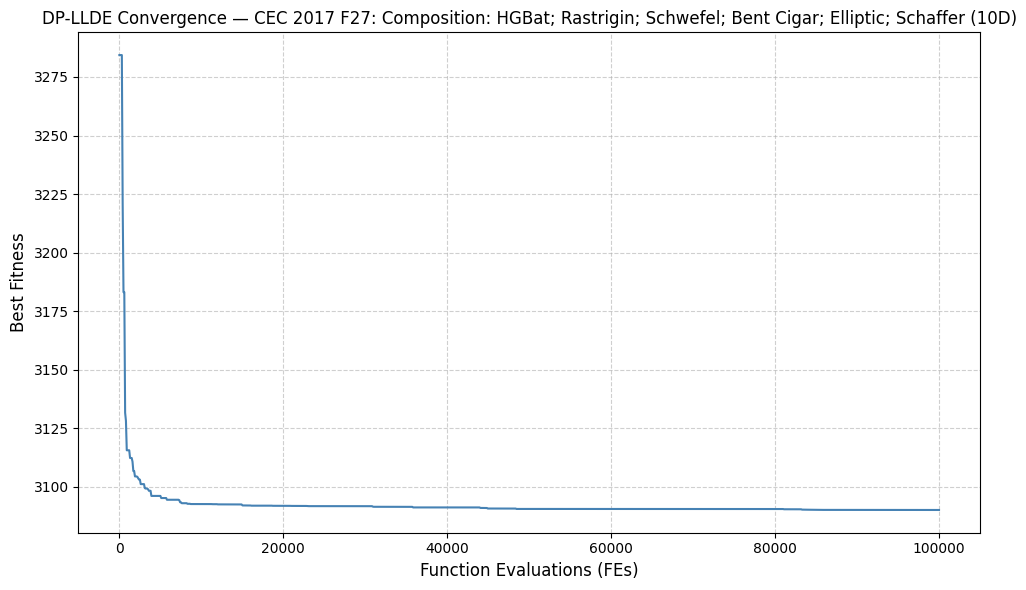

Graph saved as convergence_F27.png



In [36]:
# ============================================================
# F27 — Composition Function 7 (HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer)
# ============================================================
run_and_plot('F27', make_wrapper(composition.f27), 2700.0, 'Composition: HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer')

DP-LLDE on CEC 2017 F28 — Single Run
Function       : Composition: Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 2800.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 4.188047e+03
Generation   10: Best = 3.621205e+03  FES =   1100  μ_F = 0.570  μ_CR = 0.357
Generation   20: Best = 3.430504e+03  FES =   2100  μ_F = 0.638  μ_CR = 0.358
Generation   30: Best = 3.413267e+03  FES =   3100  μ_F = 0.687  μ_CR = 0.368
Generation   40: Best = 3.411949e+03  FES =   4100  μ_F = 0.731  μ_CR = 0.359
Generation   50: Best = 3.411847e+03  FES =   5100  μ_F = 0.769  μ_CR = 0.364
Generation   60: Best = 3.411823e+03  FES =   6100  μ_F = 0.781  μ_CR = 0.372
Generation   70: Best = 3.411822e+03  FES =   7100  μ_F = 0.798  μ_CR = 0.373
Generation   80: Best = 3.411822e+03  FES =   8100  μ_F = 0.803  μ_CR = 0.374
Generation   90: Best = 3.411822e+03  FES =   9100  μ_F = 0.820  μ_CR = 0.375
Generatio

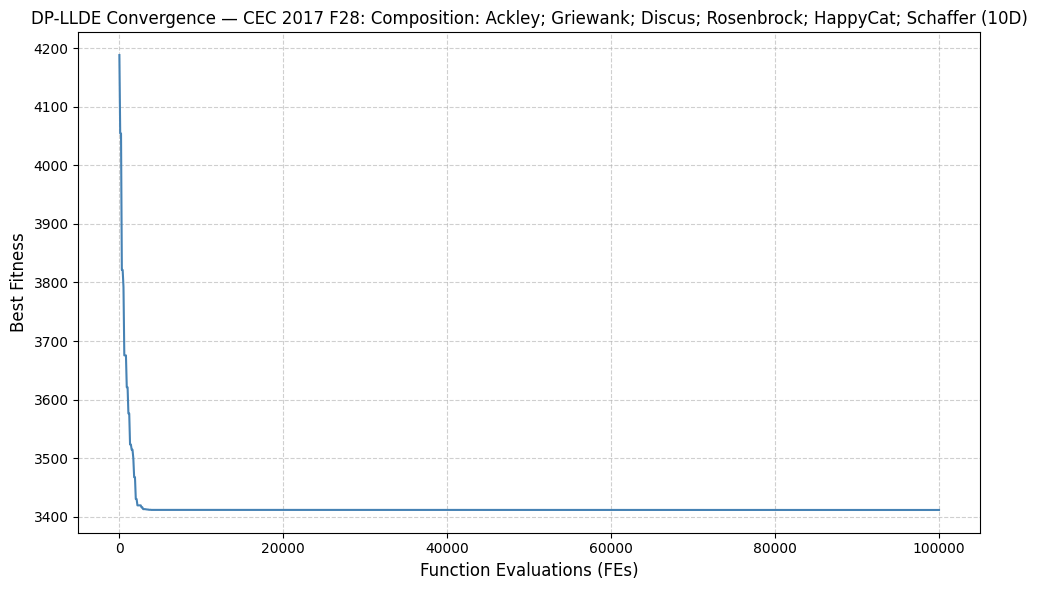

Graph saved as convergence_F28.png



In [37]:
# ============================================================
# F28 — Composition Function 8 (Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer)
# ============================================================
run_and_plot('F28', make_wrapper(composition.f28), 2800.0, 'Composition: Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer')

DP-LLDE on CEC 2017 F29 — Single Run
Function       : Composition: F15; F16; F17 (10D)
Bounds         : [-100, 100]
Global optimum : 2900.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.805371e+03
Generation   10: Best = 3.435360e+03  FES =   1100  μ_F = 0.588  μ_CR = 0.348
Generation   20: Best = 3.307691e+03  FES =   2100  μ_F = 0.650  μ_CR = 0.330
Generation   30: Best = 3.250180e+03  FES =   3100  μ_F = 0.687  μ_CR = 0.323
Generation   40: Best = 3.250180e+03  FES =   4100  μ_F = 0.770  μ_CR = 0.324
Generation   50: Best = 3.250180e+03  FES =   5100  μ_F = 0.768  μ_CR = 0.278
Generation   60: Best = 3.250180e+03  FES =   6100  μ_F = 0.792  μ_CR = 0.251
Generation   70: Best = 3.250180e+03  FES =   7100  μ_F = 0.788  μ_CR = 0.229
Generation   80: Best = 3.250180e+03  FES =   8100  μ_F = 0.762  μ_CR = 0.218
Generation   90: Best = 3.250180e+03  FES =   9100  μ_F = 0.809  μ_CR = 0.169
Generation  100: Best = 3.250180e+03  FES =  10100  

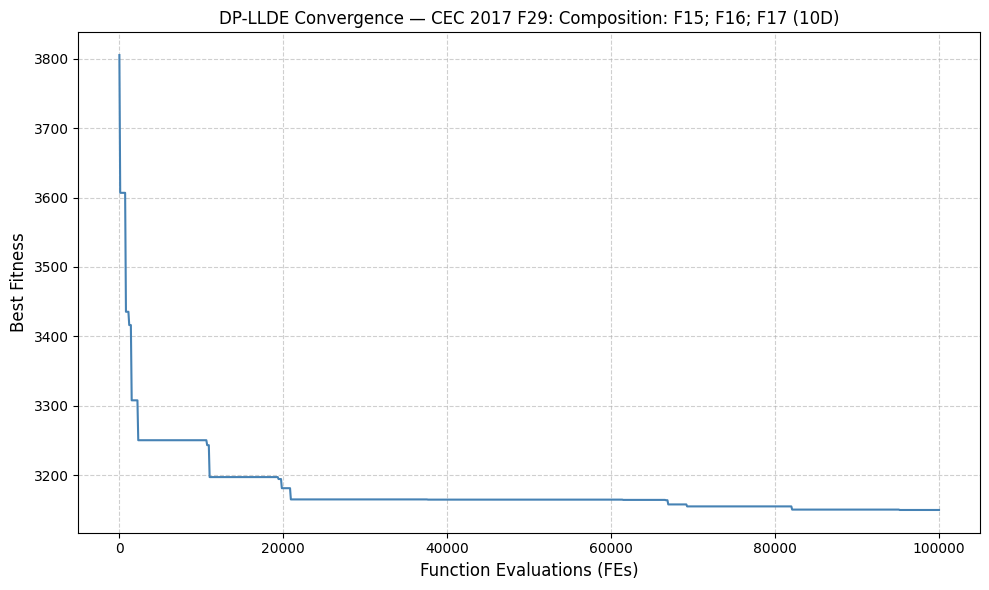

Graph saved as convergence_F29.png



In [38]:
# ============================================================
# F29 — Composition Function 9 (F15; F16; F17)
# ============================================================
run_and_plot('F29', make_wrapper(composition.f29), 2900.0, 'Composition: F15; F16; F17')

DP-LLDE on CEC 2017 F30 — Single Run
Function       : Composition: F15; F18; F19 (10D)
Bounds         : [-100, 100]
Global optimum : 3000.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.165390e+08
Generation   10: Best = 1.705750e+07  FES =   1100  μ_F = 0.562  μ_CR = 0.339
Generation   20: Best = 1.931435e+06  FES =   2100  μ_F = 0.630  μ_CR = 0.350
Generation   30: Best = 1.931435e+06  FES =   3100  μ_F = 0.684  μ_CR = 0.323
Generation   40: Best = 1.931435e+06  FES =   4100  μ_F = 0.736  μ_CR = 0.282
Generation   50: Best = 1.931435e+06  FES =   5100  μ_F = 0.779  μ_CR = 0.251
Generation   60: Best = 1.558576e+06  FES =   6100  μ_F = 0.787  μ_CR = 0.200
Generation   70: Best = 1.558576e+06  FES =   7100  μ_F = 0.817  μ_CR = 0.165
Generation   80: Best = 1.241456e+06  FES =   8100  μ_F = 0.820  μ_CR = 0.153
Generation   90: Best = 1.241456e+06  FES =   9100  μ_F = 0.840  μ_CR = 0.141
Generation  100: Best = 9.037795e+05  FES =  10100  

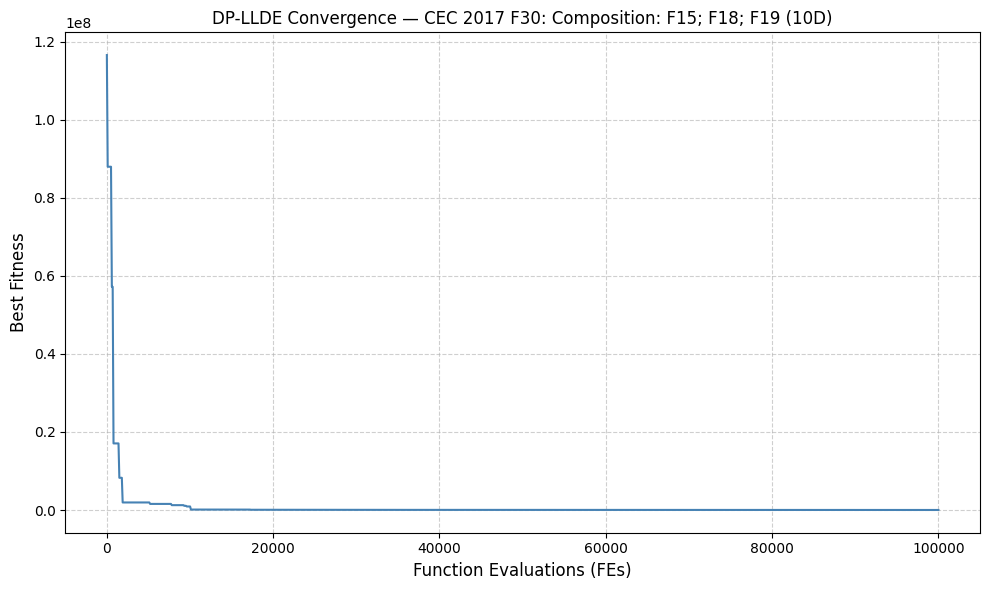

Graph saved as convergence_F30.png



In [39]:
# ============================================================
# F30 — Composition Function 10 (F15; F18; F19)
# ============================================================
run_and_plot('F30', make_wrapper(composition.f30), 3000.0, 'Composition: F15; F18; F19')

# ***Section 7. Compiled Results***

---



Print out a summary of all results in a tabular format

In [41]:
print('=' * 80)
print('SUMMARY — DP-LLDE on CEC 2017 (10D), Single Run, Seed=42')
print('=' * 80)
print(f'{"Function":<10} {"Best Fitness":>18} {"Global Optimum":>18} {"Error |best-opt|":>18}')
print('-' * 70)
for fn in [f'F{i}' for i in range(1, 31)]:
    if fn not in all_results:
        continue
    r = all_results[fn]
    if r['best_fit'] is None:
        print(f'{fn:<10} {"N/A (deprecated)":>18} {r["f_global"]:>18.2f} {"N/A":>18}')
    else:
        print(f'{fn:<10} {r["best_fit"]:>18.6e} {r["f_global"]:>18.2f} {r["error"]:>18.6e}')
print('=' * 80)

SUMMARY — DP-LLDE on CEC 2017 (10D), Single Run, Seed=42
Function         Best Fitness     Global Optimum   Error |best-opt|
----------------------------------------------------------------------
F1               1.137057e+02             100.00       1.370568e+01
F2               2.000000e+02             200.00       3.642452e-05
F3               3.118899e+02             300.00       1.188993e+01
F4               4.000000e+02             400.00       0.000000e+00
F5               5.077587e+02             500.00       7.758743e+00
F6               6.000000e+02             600.00       8.256476e-06
F7               7.156720e+02             700.00       1.567204e+01
F8               8.021592e+02             800.00       2.159158e+00
F9               9.000000e+02             900.00       0.000000e+00
F10              1.255191e+03            1000.00       2.551913e+02
F11              1.103074e+03            1100.00       3.073868e+00
F12              2.235439e+04            1200.00       2